# BTCUSD Market Regime, Direction, and Return Prediction (Clean Research Notebook)

Created: 2026-03-06

## Project Goal

Build and compare models that learn:

1. **Market Regime**
2. **Price Direction**
3. **Future Return Magnitude**

## Models to Compare

Classical:
- Logistic Regression
- Random Forest
- XGBoost

Deep Learning:
- MLP
- CNN
- GRU
- LSTM
- CNN-GRU Hybrid
- Transformer

Dataset: BTCUSD 1-minute OHLCV

Configuration:

Sequence Length = 480  
Prediction Horizon = 240


## 1. Environment Setup (Works on Kaggle or Colab)


In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 1B. Runtime, Persistence, and GPU-Saving Config

This notebook now supports a **CPU-first / GPU-later** workflow so you do not waste quota on debugging.


In [ ]:
from pathlib import Path
import random
import re

def detect_runtime():
    if os.path.exists("/teamspace/studios/this_studio"):
        return "lightning"
    if os.path.exists("/kaggle"):
        return "kaggle"
    if os.path.exists("/content"):
        return "colab"
    return "local"

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass

seed_everything(42)

RUNTIME = detect_runtime()

if RUNTIME == "lightning":
    ARTIFACT_ROOT = Path("/teamspace/studios/this_studio/artifacts/btc_research")
elif RUNTIME == "kaggle":
    ARTIFACT_ROOT = Path("/kaggle/working/btc_research")
else:
    ARTIFACT_ROOT = Path("./artifacts/btc_research")

(ARTIFACT_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)
(ARTIFACT_ROOT / "results").mkdir(parents=True, exist_ok=True)
(ARTIFACT_ROOT / "reports").mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Research defaults
# ------------------------------------------------------------
DEV_MODE = False
START_DATE = "2012-01-01"
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ------------------------------------------------------------
# Target design
# Literature and the earlier diagnostics both suggest that the
# predictive edge is stronger at shorter horizons than at 30 min.
# We therefore move to a 10-minute binary direction task.
# ------------------------------------------------------------
HORIZON = 10
DIRECTION_CLASS_IDS = [0, 1]   # 0 = Down, 1 = Up
NUM_DIRECTION_CLASSES = len(DIRECTION_CLASS_IDS)

# ------------------------------------------------------------
# Sequence setup
# Use a larger train stride to reduce near-duplicate windows and
# improve out-of-sample generalization. Evaluate with stride=HORIZON
# so validation / test do not use heavily overlapping labels.
# ------------------------------------------------------------
SEQ_LEN_FULL = 240
SEQ_LEN_DEV = 240

TRAIN_STRIDE_FULL = 10
TRAIN_STRIDE_DEV = 10

VAL_STRIDE_FULL = 10
VAL_STRIDE_DEV = 10

TEST_STRIDE_FULL = 10
TEST_STRIDE_DEV = 10

BATCH_SIZE_FULL = 64
BATCH_SIZE_DEV = 32

EPOCHS_FULL = 24
EPOCHS_DEV = 16

BASELINE_TRAIN_STRIDE_FULL = 10
BASELINE_TRAIN_STRIDE_DEV = 10

BASELINE_VAL_STRIDE_FULL = 10
BASELINE_VAL_STRIDE_DEV = 10

BASELINE_TEST_STRIDE_FULL = 10
BASELINE_TEST_STRIDE_DEV = 10

MAX_TRAIN_ROWS_DEV = 800_000
MAX_VAL_ROWS_DEV = 200_000
MAX_TEST_ROWS_DEV = 200_000

SEQ_LEN = SEQ_LEN_DEV if DEV_MODE else SEQ_LEN_FULL
TRAIN_STRIDE = TRAIN_STRIDE_DEV if DEV_MODE else TRAIN_STRIDE_FULL
VAL_STRIDE = VAL_STRIDE_DEV if DEV_MODE else VAL_STRIDE_FULL
TEST_STRIDE = TEST_STRIDE_DEV if DEV_MODE else TEST_STRIDE_FULL

BATCH_SIZE = BATCH_SIZE_DEV if DEV_MODE else BATCH_SIZE_FULL
DEFAULT_EPOCHS = EPOCHS_DEV if DEV_MODE else EPOCHS_FULL

BASELINE_TRAIN_STRIDE = BASELINE_TRAIN_STRIDE_DEV if DEV_MODE else BASELINE_TRAIN_STRIDE_FULL
BASELINE_VAL_STRIDE = BASELINE_VAL_STRIDE_DEV if DEV_MODE else BASELINE_VAL_STRIDE_FULL
BASELINE_TEST_STRIDE = BASELINE_TEST_STRIDE_DEV if DEV_MODE else BASELINE_TEST_STRIDE_FULL

STRIDE = TRAIN_STRIDE
BASELINE_STRIDE = BASELINE_TRAIN_STRIDE
EVAL_STRIDE = VAL_STRIDE

# ------------------------------------------------------------
# Evaluation gap to reduce target-overlap contamination
# ------------------------------------------------------------
PURGE_GAP = HORIZON

# ------------------------------------------------------------
# Training / regularization
# ------------------------------------------------------------
USE_WEIGHTED_SAMPLER = False
LABEL_SMOOTHING = 0.02
USE_AMP = True
FEATURE_CLIP_VALUE = 20.0

# ------------------------------------------------------------
# Stable loss / imbalance handling
# Binary direction task:
# 0 = Down, 1 = Up
# ------------------------------------------------------------
LOSS_NAME = "cross_entropy"
FOCAL_GAMMA = 2.0
CLASS_WEIGHT_POWER = 1.00
DOMINANT_CLASS_INDEX = 1
DOMINANT_CLASS_DOWNSCALE = 1.00
MINORITY_CLASS_UPSCALE = 1.00

BASELINE_USE_HARD_CLASS_WEIGHTS = False

print("RUNTIME:", RUNTIME)
print("DEVICE :", DEVICE)
print("ARTIFACT_ROOT:", ARTIFACT_ROOT)
print("DEV_MODE:", DEV_MODE)
print("HORIZON:", HORIZON, "| NUM_DIRECTION_CLASSES:", NUM_DIRECTION_CLASSES)
print(
    "SEQ_LEN:", SEQ_LEN,
    "| TRAIN_STRIDE:", TRAIN_STRIDE,
    "| VAL_STRIDE:", VAL_STRIDE,
    "| TEST_STRIDE:", TEST_STRIDE,
    "| BATCH_SIZE:", BATCH_SIZE,
    "| DEFAULT_EPOCHS:", DEFAULT_EPOCHS
)
print(
    "BASELINE_TRAIN_STRIDE:", BASELINE_TRAIN_STRIDE,
    "| BASELINE_VAL_STRIDE:", BASELINE_VAL_STRIDE,
    "| BASELINE_TEST_STRIDE:", BASELINE_TEST_STRIDE
)
print("PURGE_GAP:", PURGE_GAP)
print("USE_WEIGHTED_SAMPLER:", USE_WEIGHTED_SAMPLER, "| LABEL_SMOOTHING:", LABEL_SMOOTHING)
print("USE_AMP:", USE_AMP, "| FEATURE_CLIP_VALUE:", FEATURE_CLIP_VALUE)
print("LOSS_NAME:", LOSS_NAME, "| FOCAL_GAMMA:", FOCAL_GAMMA)
print("CLASS_WEIGHT_POWER:", CLASS_WEIGHT_POWER, "| DOMINANT_CLASS_INDEX:", DOMINANT_CLASS_INDEX)
print("DOMINANT_CLASS_DOWNSCALE:", DOMINANT_CLASS_DOWNSCALE, "| MINORITY_CLASS_UPSCALE:", MINORITY_CLASS_UPSCALE)
print("BASELINE_USE_HARD_CLASS_WEIGHTS:", BASELINE_USE_HARD_CLASS_WEIGHTS)

# ------------------------------------------------------------
# Plot / artifact helpers
# ------------------------------------------------------------
def sanitize_artifact_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(name)).strip("_")

def savefig_artifact(name: str, dpi: int = 220):
    safe = sanitize_artifact_name(name)
    path = ARTIFACT_ROOT / "reports" / f"{safe}.png"
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)
    return path

# ------------------------------------------------------------
# Multitask loss weights
# Keep direction primary, use regime and return as auxiliary tasks.
# ------------------------------------------------------------
MULTITASK_DIR_W = 1.0
MULTITASK_REG_W = 0.20
MULTITASK_RET_W = 0.10

print("MULTITASK_DIR_W:", MULTITASK_DIR_W, "| MULTITASK_REG_W:", MULTITASK_REG_W, "| MULTITASK_RET_W:", MULTITASK_RET_W)


RUNTIME: lightning
DEVICE : cuda
ARTIFACT_ROOT: /teamspace/studios/this_studio/artifacts/btc_research
DEV_MODE: False
HORIZON: 10 | NUM_DIRECTION_CLASSES: 2
SEQ_LEN: 240 | TRAIN_STRIDE: 10 | VAL_STRIDE: 10 | TEST_STRIDE: 10 | BATCH_SIZE: 64 | DEFAULT_EPOCHS: 24
BASELINE_TRAIN_STRIDE: 10 | BASELINE_VAL_STRIDE: 10 | BASELINE_TEST_STRIDE: 10
PURGE_GAP: 10
USE_WEIGHTED_SAMPLER: False | LABEL_SMOOTHING: 0.02
USE_AMP: True | FEATURE_CLIP_VALUE: 20.0
LOSS_NAME: cross_entropy | FOCAL_GAMMA: 2.0
CLASS_WEIGHT_POWER: 1.0 | DOMINANT_CLASS_INDEX: 1
DOMINANT_CLASS_DOWNSCALE: 1.0 | MINORITY_CLASS_UPSCALE: 1.0
BASELINE_USE_HARD_CLASS_WEIGHTS: False
MULTITASK_DIR_W: 1.0 | MULTITASK_REG_W: 0.2 | MULTITASK_RET_W: 0.1


## 2. Dataset Path (Kaggle / Colab Compatible)


In [ ]:
# Optional Google Drive mount for Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
except Exception:
    print("Not running in Colab or Drive mount skipped.")


Not running in Colab or Drive mount skipped.


In [ ]:
from pathlib import Path
import os

# -----------------------------------------------------------
# Detect environment
# -----------------------------------------------------------

if os.path.exists("/kaggle/working"):
    ENV = "kaggle"
    ROOT = Path("/kaggle/working")

elif os.path.exists("/teamspace/studios/this_studio"):
    ENV = "lightning"
    ROOT = Path("/teamspace/studios/this_studio")

elif os.path.exists("/content"):
    ENV = "colab"

    # if google drive mounted
    if os.path.exists("/content/drive"):
        ROOT = Path("/content/drive/MyDrive")
    else:
        ROOT = Path("/content")

else:
    ENV = "local"
    ROOT = Path.cwd()

print("Running environment:", ENV)
print("Root directory:", ROOT)

# -----------------------------------------------------------
# Project directories
# -----------------------------------------------------------

PROJECT_ROOT = ROOT / "btc_research"

REPORT_DIR = PROJECT_ROOT / "reports"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for p in [PROJECT_ROOT, REPORT_DIR, RESULTS_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Reports:", REPORT_DIR)
print("Results:", RESULTS_DIR)
print("Checkpoints:", CHECKPOINT_DIR)

Running environment: lightning
Root directory: /teamspace/studios/this_studio
Project root: /teamspace/studios/this_studio/btc_research
Reports: /teamspace/studios/this_studio/btc_research/reports
Results: /teamspace/studios/this_studio/btc_research/results
Checkpoints: /teamspace/studios/this_studio/btc_research/checkpoints


In [ ]:
import os
import glob

# Optional override (leave None normally)
DATA_PATH_OVERRIDE = None

COLAB_DEFAULT = "/content/drive/MyDrive/Colab Notebooks/Deep Learning Project/btcusd_1-min_data.csv"

def resolve_csv_path():

    # 1️⃣ Manual override
    if DATA_PATH_OVERRIDE and os.path.exists(DATA_PATH_OVERRIDE):
        return DATA_PATH_OVERRIDE

    # 2️⃣ Same folder as notebook (Lightning typical case)
    local_default = "btcusd_1-min_data.csv"
    if os.path.exists(local_default):
        return local_default

    # 3️⃣ Lightning workspace search
    lightning_matches = glob.glob("**/btcusd_1-min_data.csv", recursive=True)
    if len(lightning_matches) > 0:
        return lightning_matches[0]

    # 4️⃣ Kaggle dataset search
    kaggle_matches = glob.glob("/kaggle/input/**/btcusd_1-min_data.csv", recursive=True)
    if len(kaggle_matches) > 0:
        return kaggle_matches[0]

    # 5️⃣ Colab path
    if os.path.exists(COLAB_DEFAULT):
        return COLAB_DEFAULT

    raise FileNotFoundError(
        "Could not find btcusd_1-min_data.csv.\n"
        "Expected locations:\n"
        "- Notebook folder (Lightning)\n"
        "- /kaggle/input/<dataset>/\n"
        "- Google Drive (Colab)\n"
        "- Or set DATA_PATH_OVERRIDE."
    )

CSV_PATH = resolve_csv_path()
print("Using CSV_PATH:", CSV_PATH)


Using CSV_PATH: btcusd_1-min_data.csv


## 3. Load Dataset


In [ ]:

def load_btc_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Normalize columns: lowercase
    df.columns = [c.strip().lower() for c in df.columns]

    # Detect timestamp column
    if "timestamp" not in df.columns:
        # common alternatives
        for cand in ["time", "date", "datetime"]:
            if cand in df.columns:
                df = df.rename(columns={cand: "timestamp"})
                break
    if "timestamp" not in df.columns:
        raise ValueError(f"No timestamp column found. Columns: {df.columns.tolist()}")

    # Detect OHLCV
    rename_map = {}
    for col in ["open","high","low","close","volume"]:
        if col not in df.columns:
            # sometimes 'vol' or 'volumefrom'
            for cand in [col.capitalize(), col.upper(), "vol", "volumefrom", "qty"]:
                cand_l = str(cand).lower()
                if cand_l in df.columns:
                    rename_map[cand_l] = col
                    break
    if rename_map:
        df = df.rename(columns=rename_map)

    missing = [c for c in ["open","high","low","close","volume"] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing OHLCV columns: {missing}. Columns: {df.columns.tolist()}")

    # Timestamp parsing: your file uses unix seconds (e.g., 1.325e9)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").set_index("timestamp")

    # Ensure numeric OHLCV
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["open","high","low","close"])

    return df[["open","high","low","close","volume"]]

df = load_btc_csv(CSV_PATH)
print("rows:", len(df), "| range:", df.index.min(), "→", df.index.max())
df.head()


# Expect a DataFrame named df with columns: open, high, low, close, volume
print('df shape:', df.shape)
print(df.columns)
df.head()


rows: 7432962 | range: 2012-01-01 10:01:00+00:00 → 2026-02-19 00:02:00+00:00
df shape: (7432962, 5)
Index(['open', 'high', 'low', 'close', 'volume'], dtype='object')


,open,high,low,close,volume
timestamp,,,,,
2012-01-01 10:01:00+00:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:02:00+00:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:03:00+00:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:04:00+00:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:05:00+00:00,4.58,4.58,4.58,4.58,0.0


## 4. Basic Visualization


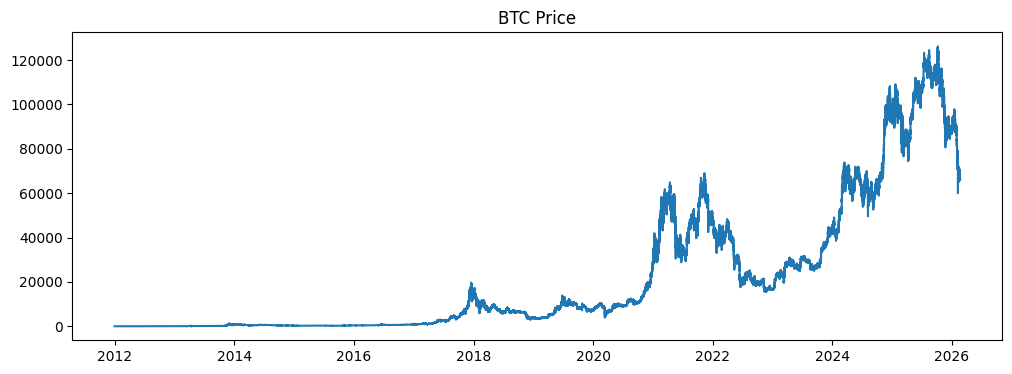

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['close'])
plt.title("BTC Price")
plt.show()


## 5. Feature Engineering — Curated Features for Generalization


In [ ]:

# ===== Trim early to reduce memory footprint =====
if "df" not in globals():
    raise NameError("df is not defined yet. Run the data-loading cell above first.")

if hasattr(df, "index") and str(df.index.dtype).startswith("datetime"):
    pass
else:
    if "Timestamp" in df.columns:
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s", errors="coerce")
        df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").set_index("Timestamp")

df = df.loc[START_DATE:].copy()
print("After START_DATE trim:", df.index.min(), "→", df.index.max(), "rows:", len(df))


After START_DATE trim: 2012-01-01 10:01:00+00:00 → 2026-02-19 00:02:00+00:00 rows: 7432962


In [ ]:
# ------------------------------------------------------------
# Expanded stationary / relative feature engineering for finance.
# Features added here were chosen to improve generalization:
# - raw OHLCV in log / relative form
# - short-horizon momentum at 2, 3, 10 minutes
# - realized volatility and volatility ratios
# - trend persistence / flip counts
# - range compression / expansion
# All features are leakage-safe and use only information available at t.
# ------------------------------------------------------------
eps = 1e-8

# Base transforms
df['log_open'] = np.log(df['open'].clip(lower=eps))
df['log_high'] = np.log(df['high'].clip(lower=eps))
df['log_low'] = np.log(df['low'].clip(lower=eps))
df['log_close'] = np.log(df['close'].clip(lower=eps))
df['log_volume'] = np.log1p(df['volume'].clip(lower=0.0))

# Raw OHLCV in relative / scale-friendly form
df['open_rel_prev_close'] = df['open'] / df['close'].shift(1).replace(0, np.nan) - 1
df['high_rel_prev_close'] = df['high'] / df['close'].shift(1).replace(0, np.nan) - 1
df['low_rel_prev_close'] = df['low'] / df['close'].shift(1).replace(0, np.nan) - 1
df['close_rel_prev_close'] = df['close'] / df['close'].shift(1).replace(0, np.nan) - 1

# Returns / momentum
df['ret_1'] = df['close'].pct_change()
df['ret_2'] = df['close'].pct_change(2)
df['ret_3'] = df['close'].pct_change(3)
df['ret_5'] = df['close'].pct_change(5)
df['ret_10'] = df['close'].pct_change(10)
df['ret_15'] = df['close'].pct_change(15)
df['ret_30'] = df['close'].pct_change(30)
df['ret_60'] = df['close'].pct_change(60)
df['ret_240'] = df['close'].pct_change(240)

df['log_ret_1'] = df['log_close'].diff()
df['log_ret_2'] = df['log_close'].diff(2)
df['log_ret_3'] = df['log_close'].diff(3)
df['log_ret_5'] = df['log_close'].diff(5)
df['log_ret_10'] = df['log_close'].diff(10)
df['log_ret_15'] = df['log_close'].diff(15)
df['log_ret_60'] = df['log_close'].diff(60)

# Candle shape / intrabar structure
df['hl_spread'] = (df['high'] - df['low']) / df['close'].replace(0, np.nan)
df['oc_spread'] = (df['close'] - df['open']) / df['open'].replace(0, np.nan)
df['co_spread'] = (df['open'] - df['close'].shift(1)) / df['close'].shift(1).replace(0, np.nan)

df['body'] = df['close'] - df['open']
df['range'] = (df['high'] - df['low']).replace(0, np.nan)
df['body_ratio'] = df['body'] / df['range']
df['price_pressure'] = df['body'] / df['range']
df['upper_wick'] = (df['high'] - np.maximum(df['open'], df['close'])) / df['close'].replace(0, np.nan)
df['lower_wick'] = (np.minimum(df['open'], df['close']) - df['low']) / df['close'].replace(0, np.nan)

# Moving averages / trend anchors
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['ema_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()

# Relative trend features
df['price_vs_sma20'] = df['close'] / df['sma_20'] - 1
df['price_vs_sma50'] = df['close'] / df['sma_50'] - 1
df['ema_gap_20'] = df['close'] / df['ema_20'] - 1
df['sma20_vs_sma50'] = df['sma_20'] / df['sma_50'] - 1
df['trend_strength'] = df['ema_20'] / df['ema_100'] - 1

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi'] = 100 - (100 / (1 + rs))
df['rsi_centered'] = (df['rsi'] - 50.0) / 50.0

# Volatility
df['volatility_5'] = df['ret_1'].rolling(5).std()
df['volatility_15'] = df['ret_1'].rolling(15).std()
df['volatility_30'] = df['ret_1'].rolling(30).std()
df['volatility_60'] = df['ret_1'].rolling(60).std()
df['volatility_120'] = df['ret_1'].rolling(120).std()
df['volatility_240'] = df['ret_1'].rolling(240).std()

# Realized volatility / regime
df['rv_15'] = np.sqrt((df['log_ret_1'] ** 2).rolling(15).sum())
df['rv_30'] = np.sqrt((df['log_ret_1'] ** 2).rolling(30).sum())
df['rv_60'] = np.sqrt((df['log_ret_1'] ** 2).rolling(60).sum())
df['volatility_ratio'] = df['volatility_15'] / df['volatility_60'].replace(0, np.nan)
df['volatility_ratio_5_60'] = df['volatility_5'] / df['volatility_60'].replace(0, np.nan)
df['volatility_ratio_15_120'] = df['volatility_15'] / df['volatility_120'].replace(0, np.nan)

# Bollinger bands
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['bb_upper'] = ma20 + 2 * std20
df['bb_lower'] = ma20 - 2 * std20
band_width = (df['bb_upper'] - df['bb_lower']).replace(0, np.nan)
df['bb_pos'] = (df['close'] - ma20) / band_width
df['bb_width'] = band_width / df['close'].replace(0, np.nan)

# Volume normalization / shocks
vol_mu_60 = df['log_volume'].rolling(60).mean()
vol_sd_60 = df['log_volume'].rolling(60).std()
df['volume_z_60'] = (df['log_volume'] - vol_mu_60) / vol_sd_60.replace(0, np.nan)
df['volume_shock'] = df['volume'] / df['volume'].rolling(60).mean().replace(0, np.nan)

# Session VWAP and distance to VWAP
if hasattr(df.index, "date"):
    session_key = pd.Series(df.index.date, index=df.index)
else:
    session_key = pd.Series(np.arange(len(df)), index=df.index)

session_pv = (df['close'] * df['volume']).groupby(session_key).cumsum()
session_v = df['volume'].groupby(session_key).cumsum().replace(0, np.nan)
df['session_vwap'] = session_pv / session_v
df['vwap_dist'] = df['close'] / df['session_vwap'] - 1

# Range / breakout / compression context
df['range_z_60'] = (df['hl_spread'] - df['hl_spread'].rolling(60).mean()) / df['hl_spread'].rolling(60).std().replace(0, np.nan)
df['high_roll_15'] = df['high'].rolling(15).max()
df['low_roll_15'] = df['low'].rolling(15).min()
df['high_roll_30'] = df['high'].rolling(30).max()
df['low_roll_30'] = df['low'].rolling(30).min()
df['high_roll_60'] = df['high'].rolling(60).max()
df['low_roll_60'] = df['low'].rolling(60).min()

df['close_to_high30'] = df['close'] / df['high_roll_30'] - 1
df['close_to_low30'] = df['close'] / df['low_roll_30'] - 1
df['high_break_30'] = (df['high'] >= df['high_roll_30'].shift(1)).astype(float)
df['low_break_30'] = (df['low'] <= df['low_roll_30'].shift(1)).astype(float)

window_range_30 = (df['high_roll_30'] - df['low_roll_30']).replace(0, np.nan)
window_range_60 = (df['high_roll_60'] - df['low_roll_60']).replace(0, np.nan)
df['range_compression_30'] = (df['high'] - df['low']) / window_range_30
df['range_compression_60'] = (df['high'] - df['low']) / window_range_60
df['range_expansion_15'] = (df['high'] - df['low']) / (df['high'] - df['low']).rolling(15).mean().replace(0, np.nan)
df['range_expansion_30'] = (df['high'] - df['low']) / (df['high'] - df['low']).rolling(30).mean().replace(0, np.nan)

# Trend persistence / flip count
trend_sign = np.sign(df['ret_1']).fillna(0.0)
run_lengths = np.zeros(len(df), dtype=np.float32)
for i in range(1, len(df)):
    if trend_sign.iloc[i] != 0 and trend_sign.iloc[i] == trend_sign.iloc[i - 1]:
        run_lengths[i] = run_lengths[i - 1] + 1.0
    elif trend_sign.iloc[i] != 0:
        run_lengths[i] = 1.0
    else:
        run_lengths[i] = 0.0
df['trend_run_length'] = run_lengths
trend_flip = (trend_sign != trend_sign.shift(1)).astype(float)
df['trend_flip_count_30'] = trend_flip.rolling(30).sum()

# Time-of-day / weekday cyclical features
if hasattr(df.index, "hour"):
    df['hour'] = df.index.hour
    df['dow'] = df.index.dayofweek
else:
    df['hour'] = 0
    df['dow'] = 0

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7.0)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7.0)

df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

print("Feature-engineered rows:", len(df))
print("Current columns:", len(df.columns))


Feature-engineered rows: 5140625
Current columns: 93


## 6. Future Return Target


In [ ]:
# Use log-return for a more symmetric future target.
df['future_return'] = df['close'].shift(-HORIZON) / df['close'] - 1
df['future_log_return'] = np.log(df['close'].shift(-HORIZON) / df['close'])

df.dropna(inplace=True)

print("Rows after future target creation:", len(df))


Rows after future target creation: 5140615


## 7. Direction Labels (Binary Up / Down)


In [ ]:
# ------------------------------------------------------------
# Binary direction label:
# 0 = Down, 1 = Up
# We remove the neutral class so the task focuses on directional
# discrimination, which is often more informative for trading models.
# ------------------------------------------------------------
df['direction'] = (df['future_log_return'] > 0).astype(np.int64)

print("Overall direction distribution:", df['direction'].value_counts(normalize=True).sort_index().round(4).to_dict())
train_cut_for_label = int(len(df) * TRAIN_RATIO)
print("Train-slice direction distribution:", df['direction'].iloc[:train_cut_for_label].value_counts(normalize=True).sort_index().round(4).to_dict())


Overall direction distribution: {0: 0.4961, 1: 0.5039}
Train-slice direction distribution: {0: 0.4937, 1: 0.5063}


## 8. Regime Labels


In [ ]:
# ------------------------------------------------------------
# Regime features (past-only)
# Balanced 3-class trend regime using train-only tertiles
# ------------------------------------------------------------

# Past-only trend score
df['trend_ma_240'] = df['close'].rolling(240).mean()
df['trend_score'] = (df['close'] - df['trend_ma_240']) / (df['trend_ma_240'] + 1e-12)

# Keep volatility as a feature if you still want it elsewhere
df['volatility'] = df['ret_1'].rolling(240).std()

# Temporary placeholder; overwritten after chronological split
df['regime'] = 1


## 9. Integrated Model Feature Set (Selected Important Features)


In [ ]:
# NOTE:
# `feature_cols` below is the integrated feature set used by BOTH
# the classical baselines and the deep sequence models in the main flow.
#
# Design principle:
# - keep OHLCV information available
# - use stationary / relative versions for better generalization
# - include literature-guided regime-supporting features that often help
#   financial generalization at short horizons
# - avoid obvious duplicates that inflate variance without adding signal
#
# Important:
# - direction and return targets are already available at this stage
# - regime labels are intentionally deferred until AFTER the chronological
#   split so the regime boundaries can be estimated from the TRAIN split only
# - this avoids contamination from validation / test periods

feature_cols = [
    # OHLCV channels (stationary / scale-friendly)
    'log_open', 'log_high', 'log_low', 'log_close', 'log_volume',
    'open_rel_prev_close', 'high_rel_prev_close', 'low_rel_prev_close', 'close_rel_prev_close',

    # Momentum
    'ret_1', 'ret_2', 'ret_3', 'ret_5', 'ret_10', 'ret_15', 'ret_30', 'ret_60', 'ret_240',

    # Candle / bar structure
    'hl_spread', 'body_ratio', 'price_pressure', 'upper_wick', 'lower_wick',

    # Trend / mean-reversion state
    'price_vs_sma20', 'trend_strength', 'rsi_centered',
    'trend_run_length', 'trend_flip_count_30',

    # Volatility regime / scale state
    'volatility_5', 'volatility_15', 'volatility_30', 'volatility_60', 'volatility_120',
    'rv_15', 'rv_30', 'rv_60',
    'volatility_ratio', 'volatility_ratio_5_60', 'volatility_ratio_15_120',
    'bb_width',

    # Volume / session location
    'volume_z_60', 'volume_shock', 'vwap_dist',

    # Range / breakout location
    'range_z_60', 'close_to_high30', 'close_to_low30',
    'high_break_30', 'low_break_30',
    'range_compression_30', 'range_compression_60',
    'range_expansion_15', 'range_expansion_30',

    # Time structure
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

excluded_redundant_features = [
    'log_ret_1', 'log_ret_2', 'log_ret_3', 'log_ret_5', 'log_ret_10', 'log_ret_15', 'log_ret_60',
    'oc_spread', 'co_spread',
    'price_vs_sma50', 'ema_gap_20', 'sma20_vs_sma50',
    'volatility_240',
    'bb_pos',
    'volume_pct_1', 'volume_rel_prev'
]

print("Selected integrated features:", len(feature_cols))
print("Excluded mostly redundant / lower-value features:", excluded_redundant_features)

X_all = df[feature_cols].to_numpy(dtype=np.float32)
y_dir_all = df['direction'].to_numpy(dtype=np.int64)
y_reg_all = None  # built AFTER chronological split using TRAIN-only regime cut points
y_ret_all = df['future_log_return'].to_numpy(dtype=np.float32)

print("Number of model features used by BOTH baselines and deep models:", len(feature_cols))
print("Raw feature matrix:", X_all.shape)
print("Direction labels   :", y_dir_all.shape)
print("Regime labels      :", "deferred until post-split train-only regime construction")
print("Return targets     :", y_ret_all.shape)
print("Approx feature memory (MB):", round(X_all.nbytes / (1024**2), 2))
print("Raw NaN count:", int(np.isnan(X_all).sum()), "| Raw Inf count:", int(np.isinf(X_all).sum()))

# Clean non-finite values once here so models do not explode.
X_all = np.where(np.isfinite(X_all), X_all, np.nan)
col_median = np.nanmedian(X_all, axis=0)
col_median = np.where(np.isfinite(col_median), col_median, 0.0).astype(np.float32)

inds = np.where(np.isnan(X_all))
if len(inds[0]) > 0:
    X_all[inds] = np.take(col_median, inds[1])

# Clip extremes BEFORE standardization
X_all = np.clip(X_all, -FEATURE_CLIP_VALUE, FEATURE_CLIP_VALUE).astype(np.float32)

print("After cleaning -> finite:", bool(np.isfinite(X_all).all()))

# Quick global direction summary only
dir_vals, dir_counts = np.unique(y_dir_all, return_counts=True)
print("Full direction distribution:", {int(v): round(c / len(y_dir_all), 4) for v, c in zip(dir_vals, dir_counts)})


Selected integrated features: 56
Excluded mostly redundant / lower-value features: ['log_ret_1', 'log_ret_2', 'log_ret_3', 'log_ret_5', 'log_ret_10', 'log_ret_15', 'log_ret_60', 'oc_spread', 'co_spread', 'price_vs_sma50', 'ema_gap_20', 'sma20_vs_sma50', 'volatility_240', 'bb_pos', 'volume_pct_1', 'volume_rel_prev']
Number of model features used by BOTH baselines and deep models: 56
Raw feature matrix: (5140615, 56)
Direction labels   : (5140615,)
Regime labels      : deferred until post-split train-only regime construction
Return targets     : (5140615,)
Approx feature memory (MB): 1098.15
Raw NaN count: 0 | Raw Inf count: 0
After cleaning -> finite: True
Full direction distribution: {0: 0.4961, 1: 0.5039}


## 10. Train / Validation / Test Split (Chronological, Raw Rows)


In [ ]:
n = len(df)

train_end = int(n * TRAIN_RATIO)
val_end_nominal = int(n * (TRAIN_RATIO + VAL_RATIO))

val_start = min(train_end + PURGE_GAP, n)
val_end = max(val_start, min(val_end_nominal, n))
test_start = min(val_end + PURGE_GAP, n)

# ------------------------------------------------------------
# Regime labels with TRAIN-only balanced trend tertiles
# This avoids using validation / test distribution information when
# defining the auxiliary regime target, and avoids the giant default
# class created by the earlier volatility-threshold rule.
#
# Regime definition:
#   0 = bearish
#   1 = neutral
#   2 = bullish
# based on train-only tertiles of past-only trend_score.
# ------------------------------------------------------------
train_trend_scores = df['trend_score'].iloc[:train_end].to_numpy(dtype=np.float32)
train_trend_scores = train_trend_scores[np.isfinite(train_trend_scores)]

if len(train_trend_scores) == 0:
    raise ValueError("No finite train trend_score values found for regime construction.")

trend_q1 = float(np.quantile(train_trend_scores, 1 / 3))
trend_q2 = float(np.quantile(train_trend_scores, 2 / 3))

trend_score_np = df['trend_score'].to_numpy(dtype=np.float32)
regime_np = np.full(n, 1, dtype=np.int64)  # default neutral for non-finite early rows

finite_mask = np.isfinite(trend_score_np)
regime_np[finite_mask & (trend_score_np <= trend_q1)] = 0
regime_np[finite_mask & (trend_score_np >= trend_q2)] = 2
regime_np[finite_mask & (trend_score_np > trend_q1) & (trend_score_np < trend_q2)] = 1

df['regime'] = regime_np
y_reg_all = regime_np.astype(np.int64)

def summarize_split_labels(name, y_dir, y_reg):
    dir_counts = pd.Series(y_dir).value_counts(normalize=True).sort_index().round(4).to_dict()
    reg_counts = pd.Series(y_reg).value_counts(normalize=True).sort_index().round(4).to_dict()
    print(f"{name} direction distribution:", dir_counts)
    print(f"{name} regime distribution   :", reg_counts)

Xtr = X_all[:train_end]
Xva = X_all[val_start:val_end]
Xte = X_all[test_start:]

ytr_dir = y_dir_all[:train_end]
yva_dir = y_dir_all[val_start:val_end]
yte_dir = y_dir_all[test_start:]

ytr_reg = y_reg_all[:train_end]
yva_reg = y_reg_all[val_start:val_end]
yte_reg = y_reg_all[test_start:]

ytr_ret = y_ret_all[:train_end]
yva_ret = y_ret_all[val_start:val_end]
yte_ret = y_ret_all[test_start:]

def truncate_recent(X, y1, y2, y3, max_rows=None):
    if max_rows is None or len(X) <= max_rows:
        return X, y1, y2, y3
    return X[-max_rows:], y1[-max_rows:], y2[-max_rows:], y3[-max_rows:]

if DEV_MODE:
    Xtr, ytr_dir, ytr_reg, ytr_ret = truncate_recent(Xtr, ytr_dir, ytr_reg, ytr_ret, MAX_TRAIN_ROWS_DEV)
    Xva, yva_dir, yva_reg, yva_ret = truncate_recent(Xva, yva_dir, yva_reg, yva_ret, MAX_VAL_ROWS_DEV)
    Xte, yte_dir, yte_reg, yte_ret = truncate_recent(Xte, yte_dir, yte_reg, yte_ret, MAX_TEST_ROWS_DEV)

# Scale inputs using train statistics only. This is critical for out-of-sample generalization.
seq_scaler = StandardScaler()
Xtr = seq_scaler.fit_transform(Xtr).astype(np.float32)
Xva = seq_scaler.transform(Xva).astype(np.float32)
Xte = seq_scaler.transform(Xte).astype(np.float32)

# Final clean pass after scaling
Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
Xva = np.nan_to_num(Xva, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

print("Train raw rows:", Xtr.shape, ytr_dir.shape, ytr_reg.shape, ytr_ret.shape)
print("Val raw rows  :", Xva.shape, yva_dir.shape, yva_reg.shape, yva_ret.shape)
print("Test raw rows :", Xte.shape, yte_dir.shape, yte_reg.shape, yte_ret.shape)
print("Current sequence setup -> SEQ_LEN:", SEQ_LEN, "| TRAIN_STRIDE:", TRAIN_STRIDE, "| VAL_STRIDE:", VAL_STRIDE, "| TEST_STRIDE:", TEST_STRIDE)
print("Current baseline setup -> TRAIN:", BASELINE_TRAIN_STRIDE, "| VAL:", BASELINE_VAL_STRIDE, "| TEST:", BASELINE_TEST_STRIDE)
print("Purged split boundaries -> train_end:", train_end, "| val_start:", val_start, "| val_end:", val_end, "| test_start:", test_start)
print("Train-only trend tertiles:", round(trend_q1, 8), round(trend_q2, 8))
print("Scaled Xtr finite:", bool(np.isfinite(Xtr).all()))
print("Scaled Xva finite:", bool(np.isfinite(Xva).all()))
print("Scaled Xte finite:", bool(np.isfinite(Xte).all()))

summarize_split_labels("Train", ytr_dir, ytr_reg)
summarize_split_labels("Val  ", yva_dir, yva_reg)
summarize_split_labels("Test ", yte_dir, yte_reg)


Train raw rows: (3598430, 56) (3598430,) (3598430,) (3598430,)
Val raw rows  : (771082, 56) (771082,) (771082,) (771082,)
Test raw rows : (771083, 56) (771083,) (771083,) (771083,)
Current sequence setup -> SEQ_LEN: 240 | TRAIN_STRIDE: 10 | VAL_STRIDE: 10 | TEST_STRIDE: 10
Current baseline setup -> TRAIN: 10 | VAL: 10 | TEST: 10
Purged split boundaries -> train_end: 3598430 | val_start: 3598440 | val_end: 4369522 | test_start: 4369532
Train-only trend tertiles: -0.00206725 0.00274186
Scaled Xtr finite: True
Scaled Xva finite: True
Scaled Xte finite: True
Train direction distribution: {0: 0.4937, 1: 0.5063}
Train regime distribution   : {0: 0.3333, 1: 0.3334, 2: 0.3333}
Val   direction distribution: {0: 0.5023, 1: 0.4977}
Val   regime distribution   : {0: 0.2587, 1: 0.5143, 2: 0.227}
Test  direction distribution: {0: 0.5014, 1: 0.4986}
Test  regime distribution   : {0: 0.2781, 1: 0.4732, 2: 0.2487}


In [ ]:

def check_array(name, X):
    print(f"{name}: shape={X.shape}, dtype={X.dtype}")
    print("  NaN count:", int(np.isnan(X).sum()))
    print("  Inf count:", int(np.isinf(X).sum()))
    finite = X[np.isfinite(X)]
    if finite.size > 0:
        print("  finite min:", float(finite.min()))
        print("  finite max:", float(finite.max()))
        print("  finite mean:", float(finite.mean()))
        print("  finite std:", float(finite.std()))


def check_labels(name, y):
    vals, counts = np.unique(y, return_counts=True)
    print(f"{name}:", {int(v): int(c) for v, c in zip(vals, counts)})

check_array("Xtr", Xtr)
check_array("Xva", Xva)
check_array("Xte", Xte)
check_labels("ytr_dir", ytr_dir)
check_labels("yva_dir", yva_dir)
check_labels("yte_dir", yte_dir)


Xtr: shape=(3598430, 56), dtype=float32
  NaN count: 0
  Inf count: 0
  finite min: -223.4110107421875
  finite max: 384.69305419921875
  finite mean: -6.246869244108666e-09
  finite std: 0.9999995231628418
Xva: shape=(771082, 56), dtype=float32
  NaN count: 0
  Inf count: 0
  finite min: -23.020254135131836
  finite max: 46.83441162109375
  finite mean: -0.05826340988278389
  finite std: 0.7499105334281921
Xte: shape=(771083, 56), dtype=float32
  NaN count: 0
  Inf count: 0
  finite min: -21.207151412963867
  finite max: 35.34779739379883
  finite mean: -0.026666080579161644
  finite std: 0.8099278211593628
ytr_dir: {0: 1776417, 1: 1822013}
yva_dir: {0: 387319, 1: 383763}
yte_dir: {0: 386623, 1: 384460}


In [ ]:
Xtr = np.clip(Xtr, -8, 8)
Xva = np.clip(Xva, -8, 8)
Xte = np.clip(Xte, -8, 8)

for i, col in enumerate(feature_cols):
    print(
        f"{col:25s} | "
        f"train [{Xtr[:, i].min(): .4f}, {Xtr[:, i].max(): .4f}] | "
        f"val   [{Xva[:, i].min(): .4f}, {Xva[:, i].max(): .4f}] | "
        f"test  [{Xte[:, i].min(): .4f}, {Xte[:, i].max(): .4f}]"
    )

print("\nFinite checks:")
print("Train finite:", np.isfinite(Xtr).all())
print("Val finite  :", np.isfinite(Xva).all())
print("Test finite :", np.isfinite(Xte).all())

print("\nNaN counts:")
print("Train NaNs:", np.isnan(Xtr).sum())
print("Val NaNs  :", np.isnan(Xva).sum())
print("Test NaNs :", np.isnan(Xte).sum())


log_open                  | train [-3.9986,  1.4895] | val   [ 0.6444,  1.5275] | test  [ 1.3030,  1.8312]
log_high                  | train [-3.9995,  1.4892] | val   [ 0.6446,  1.5272] | test  [ 1.3046,  1.8312]
log_low                   | train [-4.0016,  1.4881] | val   [ 0.6440,  1.5273] | test  [ 1.3027,  1.8312]
log_close                 | train [-4.0026,  1.4894] | val   [ 0.6444,  1.5275] | test  [ 1.3025,  1.8311]
log_volume                | train [-1.1754,  6.2038] | val   [-1.1754,  3.8487] | test  [-1.1754,  3.7476]
open_rel_prev_close       | train [-8.0000,  8.0000] | val   [-7.7904,  4.5856] | test  [-4.5170,  3.9254]
high_rel_prev_close       | train [-8.0000,  8.0000] | val   [-3.2536,  8.0000] | test  [-3.5046,  8.0000]
low_rel_prev_close        | train [-8.0000,  8.0000] | val   [-8.0000,  2.6422] | test  [-8.0000,  2.8855]
close_rel_prev_close      | train [-8.0000,  8.0000] | val   [-8.0000,  8.0000] | test  [-8.0000,  8.0000]
ret_1                     | train [-8

## 11. Classical Baselines with Fixed 0.5 Threshold

These baselines are trained on chronology-safe window summary features. Instead of using a fixed 0.50 cutoff, each probabilistic baseline tunes its decision threshold on the validation split to maximize balanced accuracy. This helps prevent a model from drifting toward the more convenient class.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed yet. Run: !pip install xgboost")

def build_class_weight_dict(y, class_ids=None):
    if class_ids is None:
        class_ids = DIRECTION_CLASS_IDS
    class_probs = (
        pd.Series(y)
        .value_counts(normalize=True)
        .reindex(list(class_ids), fill_value=0.0)
    )
    weights = 1.0 / np.maximum(class_probs.to_numpy(dtype=np.float64), 1e-6)
    weights = np.power(weights, CLASS_WEIGHT_POWER)

    if DOMINANT_CLASS_INDEX in class_ids:
        dom_pos = list(class_ids).index(DOMINANT_CLASS_INDEX)
        weights[dom_pos] *= DOMINANT_CLASS_DOWNSCALE

    for i, cls in enumerate(class_ids):
        if cls != DOMINANT_CLASS_INDEX:
            weights[i] *= MINORITY_CLASS_UPSCALE

    weights = weights / weights.mean()
    return {int(cls): float(w) for cls, w in zip(class_ids, weights)}

BASELINE_CLASS_WEIGHT_DICT = build_class_weight_dict(ytr_tab) if "ytr_tab" in globals() else None
if BASELINE_CLASS_WEIGHT_DICT is not None:
    print("Using BASELINE_STRIDE =", BASELINE_STRIDE)
    print("Hard baseline class weights:", BASELINE_CLASS_WEIGHT_DICT)

def get_baseline_class_weight_dict(y, class_ids=None):
    return build_class_weight_dict(y, class_ids=class_ids)

def make_sample_weights_from_class_weight_dict(y, class_weight_dict=None):
    if class_weight_dict is None:
        class_weight_dict = get_baseline_class_weight_dict(y)
    return np.asarray([class_weight_dict[int(v)] for v in y], dtype=np.float32)


In [ ]:
def make_window_summary_features_fast(X_raw, y, seq_len, stride=10, include_minmax=False):
    X_raw = np.asarray(X_raw, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    feats = []
    labels = []

    for e in range(seq_len - 1, len(X_raw), stride):
        w = X_raw[e - seq_len + 1:e + 1]
        parts = [
            w[-1],
            w.mean(axis=0),
            w.std(axis=0),
        ]
        if include_minmax:
            parts.extend([w.min(axis=0), w.max(axis=0)])
        feat = np.concatenate(parts).astype(np.float32)
        feats.append(feat)
        labels.append(y[e])

    X_out = np.vstack(feats)
    y_out = np.asarray(labels, dtype=np.int64)
    return X_out, y_out

Xtr_tab, ytr_tab = make_window_summary_features_fast(Xtr, ytr_dir, SEQ_LEN, stride=BASELINE_TRAIN_STRIDE, include_minmax=False)
Xva_tab, yva_tab = make_window_summary_features_fast(Xva, yva_dir, SEQ_LEN, stride=BASELINE_VAL_STRIDE, include_minmax=False)
Xte_tab, yte_tab = make_window_summary_features_fast(Xte, yte_dir, SEQ_LEN, stride=BASELINE_TEST_STRIDE, include_minmax=False)

tab_feature_names = (
    [f"last__{c}" for c in feature_cols] +
    [f"mean__{c}" for c in feature_cols] +
    [f"std__{c}" for c in feature_cols]
)

print("Baseline train shape:", Xtr_tab.shape)
print("Baseline val shape  :", Xva_tab.shape)
print("Baseline test shape :", Xte_tab.shape)
print("Train NaN count:", int(np.isnan(Xtr_tab).sum()), "Inf count:", int(np.isinf(Xtr_tab).sum()))
print("Val   NaN count:", int(np.isnan(Xva_tab).sum()), "Inf count:", int(np.isinf(Xva_tab).sum()))
print("Tabular summary features (built from the integrated OHLCV + engineered set):", len(tab_feature_names))


Baseline train shape: (359820, 168)
Baseline val shape  : (77085, 168)
Baseline test shape : (77085, 168)
Train NaN count: 0 Inf count: 0
Val   NaN count: 0 Inf count: 0
Tabular summary features (built from the integrated OHLCV + engineered set): 168


In [ ]:

def evaluate_classifier(y_true, y_pred, model_name="model"):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

FIXED_THRESHOLD = 0.5

def tune_binary_threshold(y_true, proba_up, objective="bal_acc"):
    pred = (proba_up >= FIXED_THRESHOLD).astype(np.int64)
    df_thr = pd.DataFrame([{
        "threshold": float(FIXED_THRESHOLD),
        "accuracy": accuracy_score(y_true, pred),
        "bal_acc": balanced_accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "weighted_f1": f1_score(y_true, pred, average="weighted"),
        "pred_down_rate": float((pred == 0).mean()),
        "pred_up_rate": float((pred == 1).mean()),
        "objective": objective,
        "mode": "fixed_0.5",
    }])
    return df_thr.iloc[0].to_dict(), df_thr

def confidence_performance_table(y_true, proba_up):
    confidence = np.abs(proba_up - 0.5)
    rows = []
    for frac in [0.10, 0.20, 0.30, 0.50, 1.00]:
        k = max(1, int(len(confidence) * frac))
        idx = np.argsort(-confidence)[:k]
        y_hat = (proba_up[idx] >= 0.5).astype(np.int64)
        rows.append({
            "top_fraction": frac,
            "n_samples": int(k),
            "accuracy": accuracy_score(y_true[idx], y_hat),
            "bal_acc": balanced_accuracy_score(y_true[idx], y_hat),
            "macro_f1": f1_score(y_true[idx], y_hat, average="macro"),
            "avg_confidence": float(confidence[idx].mean()),
        })
    return pd.DataFrame(rows)

def plot_probability_histogram(proba_up, title, save_name):
    plt.figure(figsize=(8, 4.5))
    plt.hist(proba_up, bins=40)
    plt.title(title)
    plt.xlabel("P(Up)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.25)
    savefig_artifact(save_name)
    plt.show()

def plot_confidence_curve(conf_df, title, save_name):
    plt.figure(figsize=(7, 4.5))
    plt.plot(conf_df["top_fraction"], conf_df["accuracy"], marker="o", label="Accuracy")
    plt.plot(conf_df["top_fraction"], conf_df["bal_acc"], marker="o", label="Balanced Accuracy")
    plt.plot(conf_df["top_fraction"], conf_df["macro_f1"], marker="o", label="Macro F1")
    plt.xlabel("Top fraction by confidence")
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend()
    savefig_artifact(save_name)
    plt.show()

baseline_results = []
baseline_models = {}
baseline_thresholds = {}
baseline_threshold_tables = {}



CONFIDENCE_FILTER_LOWER = 0.30
CONFIDENCE_FILTER_UPPER = 0.70

def apply_confidence_filter(proba_up, lower=CONFIDENCE_FILTER_LOWER, upper=CONFIDENCE_FILTER_UPPER):
    proba_up = np.asarray(proba_up, dtype=np.float32)
    if not (0.0 <= lower < 0.5 < upper <= 1.0):
        raise ValueError(f"Expected 0 <= lower < 0.5 < upper <= 1, got lower={lower}, upper={upper}")
    preds = np.full(len(proba_up), -1, dtype=np.int64)  # -1 means no-trade / abstain
    preds[proba_up <= lower] = 0
    preds[proba_up >= upper] = 1
    return preds

def evaluate_confidence_filter(y_true, proba_up, lower=CONFIDENCE_FILTER_LOWER, upper=CONFIDENCE_FILTER_UPPER):
    y_true = np.asarray(y_true, dtype=np.int64)
    proba_up = np.asarray(proba_up, dtype=np.float32)

    preds = apply_confidence_filter(proba_up, lower=lower, upper=upper)
    mask = preds != -1
    n_trades = int(mask.sum())
    coverage = float(mask.mean()) if len(mask) > 0 else 0.0

    if n_trades == 0:
        return {
            "lower": float(lower),
            "upper": float(upper),
            "n_trades": 0,
            "coverage": coverage,
            "accuracy": np.nan,
            "bal_acc": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "pred_down": 0,
            "pred_up": 0,
        }

    y_trade = y_true[mask]
    pred_trade = preds[mask]
    return {
        "lower": float(lower),
        "upper": float(upper),
        "n_trades": n_trades,
        "coverage": coverage,
        "accuracy": accuracy_score(y_trade, pred_trade),
        "bal_acc": balanced_accuracy_score(y_trade, pred_trade),
        "macro_f1": f1_score(y_trade, pred_trade, average="macro"),
        "weighted_f1": f1_score(y_trade, pred_trade, average="weighted"),
        "pred_down": int((pred_trade == 0).sum()),
        "pred_up": int((pred_trade == 1).sum()),
    }

def confidence_filter_sweep(y_true, proba_up, upper_grid=(0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85)):
    rows = []
    for upper in upper_grid:
        lower = 1.0 - float(upper)
        rows.append(evaluate_confidence_filter(y_true, proba_up, lower=lower, upper=upper))
    return pd.DataFrame(rows)

def plot_confidence_filter_tradeoff(df_cf, title="Confidence Filter Tradeoff", save_name=None):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(df_cf["upper"], df_cf["accuracy"], marker="o", label="Accuracy on traded signals")
    ax1.set_xlabel("Upper probability threshold")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0.45, min(1.0, max(0.60, float(np.nanmax(df_cf["accuracy"])) + 0.03)))

    ax2 = ax1.twinx()
    ax2.plot(df_cf["upper"], df_cf["coverage"], marker="s", linestyle="--", label="Coverage")
    ax2.set_ylabel("Coverage")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    plt.title(title)
    plt.tight_layout()

    if save_name:
        out_path = REPORT_DIR / f"{save_name}.png"
        plt.savefig(out_path, dpi=160, bbox_inches="tight")
        print("Saved figure:", out_path)

    plt.show()


In [ ]:

# Logistic Regression baseline with fixed 0.5 threshold
logreg_class_weight = BASELINE_CLASS_WEIGHT_DICT if BASELINE_USE_HARD_CLASS_WEIGHTS else "balanced"

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        tol=1e-3,
        class_weight=logreg_class_weight,
        solver="saga",
        n_jobs=-1,
        verbose=0,
        random_state=42,
    ))
])

logreg.fit(Xtr_tab, ytr_tab)

val_proba_logreg = logreg.predict_proba(Xva_tab)[:, 1]
best_thr_logreg, thr_table_logreg = tune_binary_threshold(yva_tab, val_proba_logreg)
test_proba_logreg = logreg.predict_proba(Xte_tab)[:, 1]
pred_logreg = (test_proba_logreg >= best_thr_logreg["threshold"]).astype(np.int64)

row = evaluate_classifier(yte_tab, pred_logreg, "LogisticRegression")
row["threshold"] = float(best_thr_logreg["threshold"])
baseline_results.append(row)
baseline_models["LogisticRegression"] = logreg
baseline_thresholds["LogisticRegression"] = float(best_thr_logreg["threshold"])
baseline_threshold_tables["LogisticRegression"] = thr_table_logreg
print("Fixed threshold:", baseline_thresholds["LogisticRegression"])
print(baseline_results[-1])


Fixed threshold: 0.5
{'model': 'LogisticRegression', 'accuracy': 0.5090873710838685, 'bal_acc': 0.5088230778894438, 'macro_f1': 0.5076679566998568, 'weighted_f1': 0.5078047883836502, 'threshold': 0.5}


In [ ]:

# Random Forest baseline with fixed 0.5 threshold
rf_class_weight = BASELINE_CLASS_WEIGHT_DICT if BASELINE_USE_HARD_CLASS_WEIGHTS else "balanced_subsample"

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    class_weight=rf_class_weight,
)

rf.fit(Xtr_tab, ytr_tab)

val_proba_rf = rf.predict_proba(Xva_tab)[:, 1]
best_thr_rf, thr_table_rf = tune_binary_threshold(yva_tab, val_proba_rf)
test_proba_rf = rf.predict_proba(Xte_tab)[:, 1]
pred_rf = (test_proba_rf >= best_thr_rf["threshold"]).astype(np.int64)

row = evaluate_classifier(yte_tab, pred_rf, "RandomForest")
row["threshold"] = float(best_thr_rf["threshold"])
baseline_results.append(row)
baseline_models["RandomForest"] = rf
baseline_thresholds["RandomForest"] = float(best_thr_rf["threshold"])
baseline_threshold_tables["RandomForest"] = thr_table_rf
print("Fixed threshold:", baseline_thresholds["RandomForest"])
print(baseline_results[-1])


Fixed threshold: 0.5
{'model': 'RandomForest', 'accuracy': 0.5150158915482909, 'bal_acc': 0.5141960925306346, 'macro_f1': 0.5021030081011914, 'weighted_f1': 0.5025180427794089, 'threshold': 0.5}


In [ ]:

# Install XGBoost if missing
try:
    import xgboost
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost already installed")
except ImportError:
    !pip install xgboost -q
    import xgboost
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost installed")

from sklearn.utils.class_weight import compute_sample_weight

# XGBoost baseline with fixed 0.5 threshold
if XGBOOST_AVAILABLE:

    xgb_model = XGBClassifier(
        objective="binary:logistic",
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.5,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
    )

    xgb_sample_weight = (
        make_sample_weights_from_class_weight_dict(
            ytr_tab,
            get_baseline_class_weight_dict(ytr_tab)
        )
        if BASELINE_USE_HARD_CLASS_WEIGHTS
        else compute_sample_weight(class_weight="balanced", y=ytr_tab)
    )

    xgb_model.fit(Xtr_tab, ytr_tab, sample_weight=xgb_sample_weight)

    val_proba_xgb = xgb_model.predict_proba(Xva_tab)[:, 1]
    best_thr_xgb, thr_table_xgb = tune_binary_threshold(yva_tab, val_proba_xgb)
    test_proba_xgb = xgb_model.predict_proba(Xte_tab)[:, 1]
    pred_xgb = (test_proba_xgb >= best_thr_xgb["threshold"]).astype(np.int64)

    row = evaluate_classifier(yte_tab, pred_xgb, "XGBoost")
    row["threshold"] = float(best_thr_xgb["threshold"])
    baseline_results.append(row)
    baseline_models["XGBoost"] = xgb_model
    baseline_thresholds["XGBoost"] = float(best_thr_xgb["threshold"])
    baseline_threshold_tables["XGBoost"] = thr_table_xgb
    print("Fixed threshold:", baseline_thresholds["XGBoost"])
    print(baseline_results[-1])

else:
    print("Skip XGBoost until xgboost is installed.")


XGBoost already installed
Fixed threshold: 0.5
{'model': 'XGBoost', 'accuracy': 0.5106051761043005, 'bal_acc': 0.509767665661536, 'macro_f1': 0.4970035887827664, 'weighted_f1': 0.49743172331584407, 'threshold': 0.5}


In [ ]:

# MLP baseline on summary features with fixed 0.5 threshold
mlp_tab = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        batch_size=256,
        learning_rate_init=8e-4,
        alpha=5e-4,
        max_iter=3000,
        early_stopping=True,
        random_state=42,
        verbose=False,
    ))
])

mlp_tab.fit(Xtr_tab, ytr_tab)

val_proba_mlp = mlp_tab.predict_proba(Xva_tab)[:, 1]
best_thr_mlp, thr_table_mlp = tune_binary_threshold(yva_tab, val_proba_mlp)
test_proba_mlp = mlp_tab.predict_proba(Xte_tab)[:, 1]
pred_mlp_tab = (test_proba_mlp >= best_thr_mlp["threshold"]).astype(np.int64)

row = evaluate_classifier(yte_tab, pred_mlp_tab, "MLP(summary)")
row["threshold"] = float(best_thr_mlp["threshold"])
baseline_results.append(row)
baseline_models["MLP(summary)"] = mlp_tab
baseline_thresholds["MLP(summary)"] = float(best_thr_mlp["threshold"])
baseline_threshold_tables["MLP(summary)"] = thr_table_mlp
print("Fixed threshold:", baseline_thresholds["MLP(summary)"])
print(baseline_results[-1])


Fixed threshold: 0.5
{'model': 'MLP(summary)', 'accuracy': 0.509268988778621, 'bal_acc': 0.5102401226256883, 'macro_f1': 0.49188288746643694, 'weighted_f1': 0.4913963838951093, 'threshold': 0.5}


In [ ]:
baseline_results_df = pd.DataFrame(baseline_results).sort_values(['bal_acc', 'macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
baseline_results_df


,model,accuracy,bal_acc,macro_f1,weighted_f1,threshold
0,RandomForest,0.515016,0.514196,0.502103,0.502518,0.5
1,MLP(summary),0.509269,0.510240,0.491883,0.491396,0.5
2,XGBoost,0.510605,0.509768,0.497004,0.497432,0.5
3,LogisticRegression,0.509087,0.508823,0.507668,0.507805,0.5


Best baseline model: RandomForest
Fixed threshold: 0.5

True label distribution:
Counter({0: 38742, 1: 38343})

Predicted label distribution:
Counter({0: 50757, 1: 26328})

Confusion matrix:


,Pred Down,Pred Up
True Down,26057,12685
True Up,24700,13643



Classification report:
              precision    recall  f1-score   support

           0     0.5134    0.6726    0.5823     38742
           1     0.5182    0.3558    0.4219     38343

    accuracy                         0.5150     77085
   macro avg     0.5158    0.5142    0.5021     77085
weighted avg     0.5158    0.5150    0.5025     77085

Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/baseline_probability_histogram_RandomForest.png


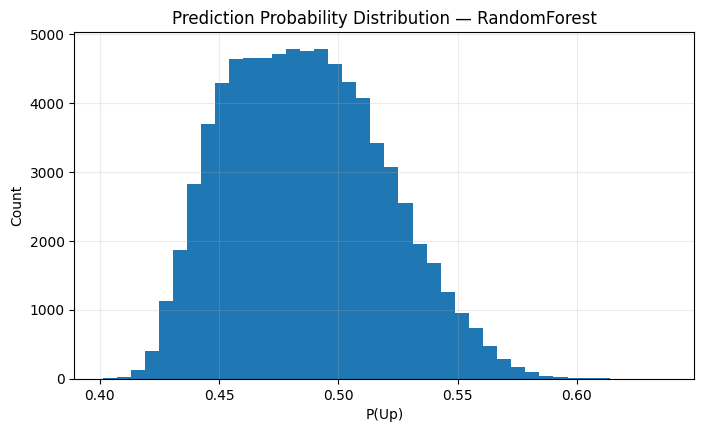


Confidence-filtered performance:


,top_fraction,n_samples,accuracy,bal_acc,macro_f1,avg_confidence
0,0.1,7708,0.542294,0.525357,0.483734,0.066317
1,0.2,15417,0.532529,0.520899,0.475692,0.059536
2,0.3,23125,0.523589,0.516655,0.473480,0.054455
3,0.5,38542,0.522287,0.517964,0.486627,0.046104
4,1.0,77085,0.515016,0.514196,0.502103,0.029555


Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/baseline_confidence_curve_RandomForest.png


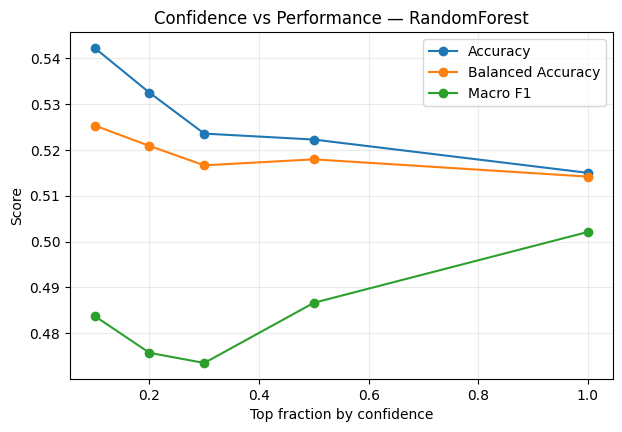

In [ ]:

# Baseline prediction distribution, confusion matrix, fixed-threshold diagnostics, and confidence plots
from collections import Counter

best_baseline_name = baseline_results_df.iloc[0]["model"]
best_baseline_model = baseline_models[best_baseline_name]
best_baseline_threshold = baseline_thresholds[best_baseline_name]

y_proba_test = best_baseline_model.predict_proba(Xte_tab)[:, 1]
y_pred_test = (y_proba_test >= best_baseline_threshold).astype(np.int64)

print("Best baseline model:", best_baseline_name)
print("Fixed threshold:", best_baseline_threshold)

print("\nTrue label distribution:")
print(Counter(yte_tab))
print("\nPredicted label distribution:")
print(Counter(y_pred_test))

cm = confusion_matrix(yte_tab, y_pred_test)
cm_df = pd.DataFrame(
    cm,
    index=["True Down", "True Up"],
    columns=["Pred Down", "Pred Up"]
)
print("\nConfusion matrix:")
display(cm_df)

print("\nClassification report:")
print(classification_report(yte_tab, y_pred_test, digits=4))

plot_probability_histogram(
    y_proba_test,
    title=f"Prediction Probability Distribution — {best_baseline_name}",
    save_name=f"baseline_probability_histogram_{best_baseline_name}"
)

confidence_df = confidence_performance_table(yte_tab, y_proba_test)
print("\nConfidence-filtered performance:")
display(confidence_df)

plot_confidence_curve(
    confidence_df,
    title=f"Confidence vs Performance — {best_baseline_name}",
    save_name=f"baseline_confidence_curve_{best_baseline_name}"
)


Baseline confidence-filter sweep:


,lower,upper,n_trades,coverage,accuracy,bal_acc,macro_f1,weighted_f1,pred_down,pred_up
0,0.45,0.55,13812,0.179179,0.534173,0.520975,0.476002,0.483409,11215,2597
1,0.40,0.60,16,0.000208,0.562500,0.500000,0.360000,0.405000,0,16
2,0.35,0.65,0,0.000000,NaN,NaN,NaN,NaN,0,0
3,0.30,0.70,0,0.000000,NaN,NaN,NaN,NaN,0,0
4,0.25,0.75,0,0.000000,NaN,NaN,NaN,NaN,0,0
5,0.20,0.80,0,0.000000,NaN,NaN,NaN,NaN,0,0
6,0.15,0.85,0,0.000000,NaN,NaN,NaN,NaN,0,0


Best baseline confidence-filter row:
{'lower': 0.4, 'upper': 0.6, 'n_trades': 16.0, 'coverage': 0.0002075630797171953, 'accuracy': 0.5625, 'bal_acc': 0.5, 'macro_f1': 0.36, 'weighted_f1': 0.40499999999999997, 'pred_down': 0.0, 'pred_up': 16.0}
Saved figure: /teamspace/studios/this_studio/btc_research/reports/baseline_confidence_filter_tradeoff_RandomForest.png


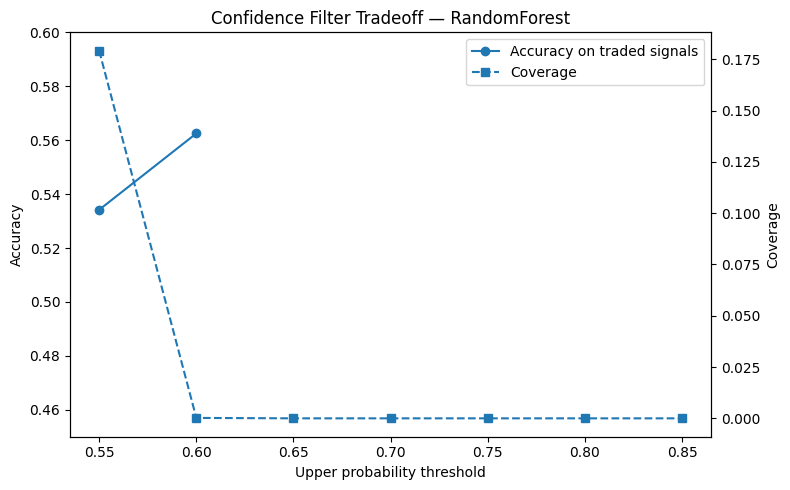

In [ ]:

# Confidence filtering for the best baseline model.
# We keep the classifier threshold fixed at 0.5 for standard evaluation, but at inference time
# we can abstain on low-confidence examples and only keep stronger signals.

baseline_cf_df = confidence_filter_sweep(
    y_true=yte_tab,
    proba_up=y_proba_test,
    upper_grid=(0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85),
)

print("Baseline confidence-filter sweep:")
display(baseline_cf_df)

baseline_cf_best = baseline_cf_df.sort_values(["accuracy", "coverage"], ascending=[False, False]).iloc[0].to_dict()
print("Best baseline confidence-filter row:")
print(baseline_cf_best)

plot_confidence_filter_tradeoff(
    baseline_cf_df,
    title=f"Confidence Filter Tradeoff — {best_baseline_name}",
    save_name=f"baseline_confidence_filter_tradeoff_{best_baseline_name}",
)


## 12. Memory-Safe Sliding Window Dataset and DataLoaders

This section converts the row-wise feature matrix into sequence windows for the deep models. The training loader uses the global training stride, while validation and test use the evaluation stride. Each sample carries three targets:

- binary direction label
- market regime label
- future return regression target


In [ ]:
from torch.utils.data import WeightedRandomSampler

class SeqDataset(Dataset):
    def __init__(
        self,
        X: np.ndarray,
        y_dir: np.ndarray,
        y_reg: np.ndarray,
        y_ret: np.ndarray,
        seq_len: int,
        stride: int = 1
    ):
        assert len(X) == len(y_dir) == len(y_reg) == len(y_ret)

        self.X = np.asarray(X, dtype=np.float32)
        self.y_dir = np.asarray(y_dir, dtype=np.int64)
        self.y_reg = np.asarray(y_reg, dtype=np.int64)
        self.y_ret = np.asarray(y_ret, dtype=np.float32)

        self.seq_len = int(seq_len)
        self.stride = int(stride)

        end_positions = np.arange(self.seq_len - 1, len(X), self.stride)
        if len(end_positions) == 0:
            raise ValueError("No valid sequence windows available.")
        self.ends = end_positions

    def __len__(self):
        return len(self.ends)

    def __getitem__(self, idx):
        e = int(self.ends[idx])
        s = e - self.seq_len + 1

        xb = self.X[s:e+1]
        if xb.ndim != 2:
            raise RuntimeError(f"Expected 2D window [seq_len, features], got shape={xb.shape}")
        if xb.shape[0] != self.seq_len:
            raise RuntimeError(f"Expected seq_len={self.seq_len}, got window rows={xb.shape[0]}")
        if not np.isfinite(xb).all():
            raise RuntimeError("Non-finite sequence window encountered in dataset.")

        yb_dir = self.y_dir[e]
        yb_reg = self.y_reg[e]
        yb_ret = self.y_ret[e]

        return (
            torch.from_numpy(xb),
            torch.tensor(yb_dir, dtype=torch.long),
            torch.tensor(yb_reg, dtype=torch.long),
            torch.tensor(yb_ret, dtype=torch.float32),
        )

NUM_WORKERS = 0 if RUNTIME in ["kaggle", "colab"] else min(4, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = bool(NUM_WORKERS > 0)

train_ds = SeqDataset(Xtr, ytr_dir, ytr_reg, ytr_ret, SEQ_LEN, TRAIN_STRIDE)
val_ds   = SeqDataset(Xva, yva_dir, yva_reg, yva_ret, SEQ_LEN, VAL_STRIDE)
test_ds  = SeqDataset(Xte, yte_dir, yte_reg, yte_ret, SEQ_LEN, TEST_STRIDE)

train_window_labels = ytr_dir[train_ds.ends]
window_class_probs = pd.Series(train_window_labels).value_counts(normalize=True).reindex(DIRECTION_CLASS_IDS, fill_value=0.0)
class_weight_vec = torch.tensor(
    (1.0 / np.maximum(window_class_probs.to_numpy(dtype=np.float32), 1e-6)),
    dtype=torch.float32
)
class_weight_vec = class_weight_vec / class_weight_vec.mean()


train_reg_window_labels = ytr_reg[train_ds.ends]
regime_class_probs = pd.Series(train_reg_window_labels).value_counts(normalize=True).reindex([0, 1, 2], fill_value=0.0)
regime_class_weight_vec = torch.tensor(
    (1.0 / np.maximum(regime_class_probs.to_numpy(dtype=np.float32), 1e-6)),
    dtype=torch.float32
)
regime_class_weight_vec = regime_class_weight_vec / regime_class_weight_vec.mean()

train_sampler = None
if USE_WEIGHTED_SAMPLER:
    inv_freq = 1.0 / np.maximum(window_class_probs.to_numpy(dtype=np.float64), 1e-9)
    sample_weights = inv_freq[train_window_labels]
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(train_sampler is None),
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)

INPUT_SIZE = Xtr.shape[1]

print("INPUT_SIZE:", INPUT_SIZE)
print("Train windows:", len(train_loader.dataset))
print("Val windows  :", len(val_loader.dataset))
print("Test windows :", len(test_loader.dataset))
print("Train class probs:", window_class_probs.to_dict())
print("Suggested CE class weights:", class_weight_vec.tolist())
print("Train regime probs:", regime_class_probs.to_dict())
print("Suggested regime CE weights:", regime_class_weight_vec.tolist())
print("NUM_WORKERS:", NUM_WORKERS, "| PIN_MEMORY:", PIN_MEMORY, "| PERSISTENT_WORKERS:", PERSISTENT_WORKERS)
print("Weighted sampler enabled:", USE_WEIGHTED_SAMPLER)

xb, yb_dir, yb_reg, yb_ret = next(iter(train_loader))
print("One-batch sanity -> xb shape:", tuple(xb.shape), "| xb finite:", bool(torch.isfinite(xb).all()))
print("One-batch y distribution:", torch.bincount(yb_dir, minlength=NUM_DIRECTION_CLASSES).tolist())


INPUT_SIZE: 56
Train windows: 359820
Val windows  : 77085
Test windows : 77085
Train class probs: {0: 0.4931215607803902, 1: 0.5068784392196098}
Suggested CE class weights: [1.0137568712234497, 0.9862431287765503]
Train regime probs: {0: 0.33339169584792394, 1: 0.33332499583124897, 2: 0.3332833083208271}
Suggested regime CE weights: [0.9998249411582947, 1.0000250339508057, 1.0001500844955444]
NUM_WORKERS: 4 | PIN_MEMORY: True | PERSISTENT_WORKERS: True
Weighted sampler enabled: False
One-batch sanity -> xb shape: (64, 240, 56) | xb finite: True
One-batch y distribution: [31, 33]


## 13. Deep Sequence Models

This section upgrades the full deep model zoo with research-backed training and architecture changes that are integrated consistently across the notebook:

- residual and normalized sequence backbones
- attention plus statistics pooling instead of only last-state pooling
- stronger temporal CNN blocks and improved recurrent encoders
- local-attention transformer with pre-norm and CLS token
- AdamW plus OneCycleLR, gradient clipping, and calibration tracking
- fair single-task versus multitask reuse of the same upgraded backbones


In [ ]:
import math

class TemporalAttentionPool(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.0):
        super().__init__()
        hidden_dim = hidden_dim or max(32, dim // 2)
        self.score = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        # x: [B, T, D]
        attn_logits = self.score(x).squeeze(-1)
        attn = torch.softmax(attn_logits, dim=1)
        pooled = torch.sum(x * attn.unsqueeze(-1), dim=1)
        return pooled, attn


class EnhancedTemporalPool(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.attn_pool = TemporalAttentionPool(dim, dropout=dropout)
        self.out_dim = dim * 4

    def forward(self, x):
        attn_vec, attn = self.attn_pool(x)
        last = x[:, -1, :]
        mean = x.mean(dim=1)
        std = x.std(dim=1, unbiased=False)
        pooled = torch.cat([attn_vec, last, mean, std], dim=1)
        return pooled, attn


def build_mlp_head(input_dim, output_dim, hidden_dim=160, dropout=0.20):
    return nn.Sequential(
        nn.LayerNorm(input_dim),
        nn.Linear(input_dim, hidden_dim),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim // 2, output_dim),
    )


class FeatureProjector(nn.Module):
    def __init__(self, input_dim, d_model, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class MixerBlock(nn.Module):
    def __init__(self, seq_len, d_model, token_hidden, channel_hidden, dropout=0.15):
        super().__init__()
        self.token_norm = nn.LayerNorm(d_model)
        self.token_mlp = nn.Sequential(
            nn.Linear(seq_len, token_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_hidden, seq_len),
            nn.Dropout(dropout),
        )
        self.channel_norm = nn.LayerNorm(d_model)
        self.channel_mlp = nn.Sequential(
            nn.Linear(d_model, channel_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(channel_hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        y = self.token_norm(x).transpose(1, 2)
        x = x + self.token_mlp(y).transpose(1, 2)
        y = self.channel_norm(x)
        x = x + self.channel_mlp(y)
        return x


class SequenceMLPMixerBackbone(nn.Module):
    def __init__(self, input_dim, seq_len, d_model=96, depth=3, dropout=0.15):
        super().__init__()
        self.project = FeatureProjector(input_dim, d_model, dropout=dropout)
        self.blocks = nn.ModuleList([
            MixerBlock(
                seq_len=seq_len,
                d_model=d_model,
                token_hidden=max(64, seq_len // 2),
                channel_hidden=d_model * 2,
                dropout=dropout,
            )
            for _ in range(depth)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.output_dim = d_model

    def forward(self, x):
        h = self.project(x)
        for block in self.blocks:
            h = block(h)
        return self.final_norm(h)


class TCNResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.10):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding, dilation=dilation),
            nn.GELU(),
            nn.GroupNorm(1, channels),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding, dilation=dilation),
            nn.GELU(),
            nn.GroupNorm(1, channels),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.block(x)


class TCNBackbone(nn.Module):
    def __init__(self, input_dim, channels=96, kernel_size=3, dilations=(1, 2, 4, 8), dropout=0.10):
        super().__init__()
        self.project = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.ModuleList([
            TCNResidualBlock(channels=channels, kernel_size=kernel_size, dilation=d, dropout=dropout)
            for d in dilations
        ])
        self.final_norm = nn.LayerNorm(channels)
        self.output_dim = channels

    def forward(self, x):
        h = self.project(x).transpose(1, 2)
        for block in self.blocks:
            h = block(h)
        h = h.transpose(1, 2)
        return self.final_norm(h)


class ResidualGRUBackbone(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True, proj_dim=96):
        super().__init__()
        self.project = FeatureProjector(input_dim, proj_dim, dropout=dropout * 0.5)
        self.gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.res_proj = nn.Linear(proj_dim, out_dim)
        self.final_norm = nn.LayerNorm(out_dim)
        self.output_dim = out_dim

    def forward(self, x):
        x_proj = self.project(x)
        h, _ = self.gru(x_proj)
        h = h + self.res_proj(x_proj)
        return self.final_norm(h)


class ResidualLSTMBackbone(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True, proj_dim=96):
        super().__init__()
        self.project = FeatureProjector(input_dim, proj_dim, dropout=dropout * 0.5)
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.res_proj = nn.Linear(proj_dim, out_dim)
        self.final_norm = nn.LayerNorm(out_dim)
        self.output_dim = out_dim

    def forward(self, x):
        x_proj = self.project(x)
        h, _ = self.lstm(x_proj)
        h = h + self.res_proj(x_proj)
        return self.final_norm(h)


class CNNGRUBackbone(nn.Module):
    def __init__(self, input_dim, conv_channels=96, hidden=96, num_layers=1, dropout=0.20, bidirectional=True):
        super().__init__()
        self.tcn = TCNBackbone(
            input_dim=input_dim,
            channels=conv_channels,
            kernel_size=3,
            dilations=(1, 2, 4, 8),
            dropout=dropout * 0.5,
        )
        self.gru = nn.GRU(
            input_size=conv_channels,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.res_proj = nn.Linear(conv_channels, out_dim)
        self.final_norm = nn.LayerNorm(out_dim)
        self.output_dim = out_dim

    def forward(self, x):
        h0 = self.tcn(x)
        h, _ = self.gru(h0)
        h = h + self.res_proj(h0)
        return self.final_norm(h)


def build_local_attention_mask(seq_len, window, device):
    idx = torch.arange(seq_len, device=device)
    dist = (idx[:, None] - idx[None, :]).abs()
    mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
    mask[dist <= window] = 0.0
    return mask


class LocalTransformerBackbone(nn.Module):
    def __init__(self, input_dim, d_model=96, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.15, local_window=32):
        super().__init__()
        self.input_proj = FeatureProjector(input_dim, d_model, dropout=dropout * 0.5)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_emb = nn.Parameter(torch.randn(1, SEQ_LEN + 1, d_model) * 0.02)
        self.local_window = int(local_window)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(d_model)
        self.output_dim = d_model

    def _get_mask(self, seq_len, device):
        mask = build_local_attention_mask(seq_len, window=self.local_window, device=device)
        mask[0, :] = 0.0
        mask[:, 0] = 0.0
        return mask

    def forward(self, x):
        bsz = x.size(0)
        h = self.input_proj(x)
        cls = self.cls_token.expand(bsz, -1, -1)
        h = torch.cat([cls, h], dim=1)
        h = h + self.pos_emb[:, :h.size(1), :]
        attn_mask = self._get_mask(h.size(1), h.device)
        h = self.encoder(h, mask=attn_mask)
        h = self.output_norm(h)
        return h


class SequenceClassifier(nn.Module):
    def __init__(self, backbone, backbone_dim, num_classes=NUM_DIRECTION_CLASSES, dropout=0.20, use_cls_token=False):
        super().__init__()
        self.backbone = backbone
        self.pool = EnhancedTemporalPool(backbone_dim, dropout=dropout * 0.5)
        self.use_cls_token = bool(use_cls_token)
        head_in = self.pool.out_dim + (backbone_dim if self.use_cls_token else 0)
        self.head = build_mlp_head(head_in, num_classes, hidden_dim=160, dropout=dropout)

    def forward(self, x):
        h = self.backbone(x)
        if self.use_cls_token:
            cls_vec = h[:, 0, :]
            seq = h[:, 1:, :]
            pooled, _ = self.pool(seq)
            logits = self.head(torch.cat([cls_vec, pooled], dim=1))
        else:
            pooled, _ = self.pool(h)
            logits = self.head(pooled)
        return logits


class DirectionMLP(nn.Module):
    def __init__(self, input_dim, seq_len, hidden1=96, hidden2=48, num_classes=NUM_DIRECTION_CLASSES):
        super().__init__()
        d_model = max(64, hidden1)
        dropout = 0.15
        backbone = SequenceMLPMixerBackbone(input_dim=input_dim, seq_len=seq_len, d_model=d_model, depth=3, dropout=dropout)
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class CNN1DModel(nn.Module):
    def __init__(self, input_dim, num_classes=NUM_DIRECTION_CLASSES):
        super().__init__()
        backbone = TCNBackbone(input_dim=input_dim, channels=96, kernel_size=3, dilations=(1, 2, 4, 8), dropout=0.12)
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=0.18)

    def forward(self, x):
        return self.model(x)


class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True, num_classes=NUM_DIRECTION_CLASSES):
        super().__init__()
        backbone = ResidualGRUBackbone(
            input_dim=input_dim,
            hidden=hidden,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            proj_dim=96,
        )
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True, num_classes=NUM_DIRECTION_CLASSES):
        super().__init__()
        backbone = ResidualLSTMBackbone(
            input_dim=input_dim,
            hidden=hidden,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            proj_dim=96,
        )
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class CNNGRUModel(nn.Module):
    def __init__(self, input_dim, hidden=96, num_classes=NUM_DIRECTION_CLASSES):
        super().__init__()
        backbone = CNNGRUBackbone(
            input_dim=input_dim,
            conv_channels=96,
            hidden=hidden,
            num_layers=1,
            dropout=0.20,
            bidirectional=True,
        )
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=0.20)

    def forward(self, x):
        return self.model(x)


class TransformerEncoderModel(nn.Module):
    def __init__(self, input_dim, d_model=96, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.15, num_classes=NUM_DIRECTION_CLASSES, local_window=32):
        super().__init__()
        backbone = LocalTransformerBackbone(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            local_window=local_window,
        )
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=dropout, use_cls_token=True)

    def forward(self, x):
        return self.model(x)


class CNNTransformerHybridBackbone(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=96,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.15,
        local_window=32,
        cnn_kernel_size=3,
        cnn_dilations=(1, 2, 4, 8),
    ):
        super().__init__()
        self.tcn = TCNBackbone(
            input_dim=input_dim,
            channels=d_model,
            kernel_size=cnn_kernel_size,
            dilations=cnn_dilations,
            dropout=dropout * 0.5,
        )
        self.transformer = LocalTransformerBackbone(
            input_dim=d_model,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            local_window=local_window,
        )
        self.output_dim = self.transformer.output_dim

    def forward(self, x):
        h = self.tcn(x)
        return self.transformer(h)


class CNNTransformerAttentionModel(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=96,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.15,
        num_classes=NUM_DIRECTION_CLASSES,
        local_window=32,
    ):
        super().__init__()
        backbone = CNNTransformerHybridBackbone(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            local_window=local_window,
        )
        self.model = SequenceClassifier(backbone, backbone.output_dim, num_classes=num_classes, dropout=dropout, use_cls_token=True)

    def forward(self, x):
        return self.model(x)


INPUT_SIZE = Xtr.shape[1]
print('INPUT_SIZE:', INPUT_SIZE)


INPUT_SIZE: 56


## 14. Unified Training and Evaluation for Deep Models


In [ ]:
import torch.nn.functional as F


def binary_brier_score(y_true, proba_up):
    y_true = np.asarray(y_true, dtype=np.float32)
    proba_up = np.asarray(proba_up, dtype=np.float32)
    return float(np.mean((proba_up - y_true) ** 2))


def expected_calibration_error(y_true, proba_up, n_bins=15):
    y_true = np.asarray(y_true, dtype=np.float32)
    proba_up = np.asarray(proba_up, dtype=np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (proba_up >= lo) & (proba_up <= hi)
        else:
            mask = (proba_up >= lo) & (proba_up < hi)
        if mask.any():
            acc = y_true[mask].mean()
            conf = proba_up[mask].mean()
            ece += float(mask.mean()) * abs(float(acc - conf))
    return float(ece)


class FocalCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits, target):
        ce = F.cross_entropy(
            logits,
            target,
            weight=self.weight,
            reduction='none',
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()


def evaluate_direction_model(model, loader, criterion, threshold=0.5):
    model.eval()
    losses = []
    y_true = []
    y_pred = []
    y_proba = []

    with torch.no_grad():
        for xb, yb_dir, yb_reg, yb_ret in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb_dir = yb_dir.to(DEVICE, non_blocking=True)

            logits = model(xb)
            if not torch.isfinite(logits).all():
                raise RuntimeError('Non-finite logits encountered during evaluation.')

            loss = criterion(logits, yb_dir)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite loss encountered during evaluation.')

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            losses.append(float(loss.item()))
            y_true.append(yb_dir.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_proba = np.concatenate(y_proba)
    return {
        'loss': float(np.mean(losses)),
        'acc': float(accuracy_score(y_true, y_pred)),
        'bal_acc': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted')),
        'brier': binary_brier_score(y_true, y_proba),
        'ece': expected_calibration_error(y_true, y_proba),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba_up': y_proba,
    }


def collect_direction_outputs(model, loader):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for xb, yb_dir, yb_reg, yb_ret in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = (probs >= 0.5).astype(np.int64)
            y_true.append(yb_dir.numpy())
            y_pred.append(preds)
            y_proba.append(probs)
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)


def get_direction_class_weights(y_window):
    class_probs = (
        pd.Series(y_window)
        .value_counts(normalize=True)
        .reindex(DIRECTION_CLASS_IDS, fill_value=0.0)
    )
    weights = 1.0 / np.maximum(class_probs.to_numpy(dtype=np.float32), 1e-6)
    weights = np.power(weights, CLASS_WEIGHT_POWER)

    if DOMINANT_CLASS_INDEX in DIRECTION_CLASS_IDS:
        dom_pos = DIRECTION_CLASS_IDS.index(int(DOMINANT_CLASS_INDEX))
        weights[dom_pos] *= DOMINANT_CLASS_DOWNSCALE

    for cls in DIRECTION_CLASS_IDS:
        if cls != int(DOMINANT_CLASS_INDEX):
            weights[DIRECTION_CLASS_IDS.index(int(cls))] *= MINORITY_CLASS_UPSCALE

    class_weight_vec = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    class_weight_vec = class_weight_vec / class_weight_vec.mean()
    return class_weight_vec


def build_direction_criterion(y_window):
    class_weight_vec = get_direction_class_weights(y_window)
    if LOSS_NAME == 'focal':
        criterion = FocalCrossEntropyLoss(
            weight=class_weight_vec,
            gamma=FOCAL_GAMMA,
            label_smoothing=LABEL_SMOOTHING,
        )
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weight_vec, label_smoothing=LABEL_SMOOTHING)
    return criterion, class_weight_vec


def _score_tuple(metrics):
    return (
        float(metrics['bal_acc']),
        float(metrics['macro_f1']),
        -float(metrics['loss']),
        -float(metrics['ece']),
    )


def train_direction_model(model_name, model, train_loader, val_loader, y_train_window, epochs=5, lr=3e-4, weight_decay=0.0, patience=5, grad_clip=1.0, pct_start=0.2):
    model = model.to(DEVICE)
    criterion, class_weight_vec = build_direction_criterion(y_train_window)
    print(f"[{model_name}] loss={LOSS_NAME} class_weight={class_weight_vec.detach().cpu().tolist()}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=pct_start,
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=50.0,
    )
    scaler = torch.amp.GradScaler(device='cuda', enabled=(USE_AMP and DEVICE == 'cuda'))

    best_state = None
    best_epoch = -1
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    wait = 0
    history = []

    print('\n' + '=' * 90)
    print(f'Training model: {model_name}')
    print('=' * 90)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb_dir, yb_reg, yb_ret in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb_dir = yb_dir.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=(USE_AMP and DEVICE == 'cuda')):
                logits = model(xb)
                loss = criterion(logits, yb_dir)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_losses.append(float(loss.item()))

        train_metrics = evaluate_direction_model(model, train_loader, criterion, threshold=0.5)
        val_metrics = evaluate_direction_model(model, val_loader, criterion, threshold=0.5)
        current_lr = optimizer.param_groups[0]['lr']
        score = _score_tuple(val_metrics)

        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['acc'],
            'train_bal_acc': train_metrics['bal_acc'],
            'train_macro_f1': train_metrics['macro_f1'],
            'train_weighted_f1': train_metrics['weighted_f1'],
            'train_brier': train_metrics['brier'],
            'train_ece': train_metrics['ece'],
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
            'val_bal_acc': val_metrics['bal_acc'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_weighted_f1': val_metrics['weighted_f1'],
            'val_brier': val_metrics['brier'],
            'val_ece': val_metrics['ece'],
            'lr': current_lr,
        })

        print(
            f"[{model_name}] Epoch {epoch:02d} | "
            f"TrainLoss {history[-1]['train_loss']:.4f} | "
            f"TrainAcc {history[-1]['train_acc']:.4f} | "
            f"TrainBalAcc {history[-1]['train_bal_acc']:.4f} | "
            f"TrainMacroF1 {history[-1]['train_macro_f1']:.4f} | "
            f"ValLoss {val_metrics['loss']:.4f} | "
            f"ValAcc {val_metrics['acc']:.4f} | "
            f"ValBalAcc {val_metrics['bal_acc']:.4f} | "
            f"ValMacroF1 {val_metrics['macro_f1']:.4f} | "
            f"ValBrier {val_metrics['brier']:.4f} | "
            f"ValECE {val_metrics['ece']:.4f} | "
            f"LR {current_lr:.2e}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f'[{model_name}] Early stopping.')
                break

    history_df = pd.DataFrame(history)
    ckpt_path = ARTIFACT_ROOT / 'checkpoints' / f"{model_name.replace('/', '_')}.pt"
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, ckpt_path)

    return history_df, model, ckpt_path, best_epoch


def tune_model_threshold_from_loader(model, loader):
    y_true, _, proba = collect_direction_outputs(model, loader)
    fixed_thr, thr_table = tune_binary_threshold(y_true, proba)
    return fixed_thr, thr_table


def run_direction_diagnostics(model, loader, threshold, model_name, split_name='test', save_prefix='deep'):
    criterion, _ = build_direction_criterion(ytr_dir[train_ds.ends])
    metrics = evaluate_direction_model(model, loader, criterion, threshold=threshold)
    y_true = metrics['y_true']
    y_pred = metrics['y_pred']
    y_proba_up = metrics['y_proba_up']

    print(f"\n{split_name.title()} predicted class distribution:")
    print(pd.Series(y_pred).value_counts().sort_index().to_dict())

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=['True Down', 'True Up'], columns=['Pred Down', 'Pred Up'])
    print('\nConfusion matrix:')
    display(cm_df)

    print('\nClassification report:')
    print(classification_report(y_true, y_pred, digits=4))

    print('\nCalibration metrics:')
    print({'brier': float(metrics['brier']), 'ece': float(metrics['ece'])})

    plot_probability_histogram(
        y_proba_up,
        title=f'Prediction Probability Distribution — {model_name} ({split_name})',
        save_name=f'{save_prefix}_probability_histogram_{model_name}_{split_name}'
    )

    conf_df = confidence_performance_table(y_true, y_proba_up)
    print('\nConfidence-filtered performance:')
    display(conf_df)

    plot_confidence_curve(
        conf_df,
        title=f'Confidence vs Performance — {model_name} ({split_name})',
        save_name=f'{save_prefix}_confidence_curve_{model_name}_{split_name}'
    )
    return metrics, conf_df, cm_df

In [ ]:
def run_torch_experiment(model_name, model, epochs=5, lr=3e-4, weight_decay=0.0, grad_clip=1.0):
    hist, model, ckpt_path, best_epoch = train_direction_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        y_train_window=ytr_dir[train_ds.ends],
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        patience=6 if DEV_MODE else 8,
        grad_clip=grad_clip,
        pct_start=0.20,
    )

    if len(hist) == 0:
        return {
            'model': model_name,
            'status': 'failed',
            'history': hist,
            'trained_model': model,
            'accuracy': np.nan,
            'bal_acc': np.nan,
            'macro_f1': np.nan,
            'weighted_f1': np.nan,
            'brier': np.nan,
            'ece': np.nan,
            'best_epoch': -1,
            'best_val_loss': np.nan,
            'checkpoint': None,
            'history_csv': None,
            'threshold': np.nan,
            'threshold_table_csv': None,
        }

    fixed_thr, thr_table = tune_model_threshold_from_loader(model, val_loader)
    criterion, _ = build_direction_criterion(ytr_dir[train_ds.ends])
    test_metrics = evaluate_direction_model(model, test_loader, criterion, threshold=float(FIXED_THRESHOLD))

    hist_path = ARTIFACT_ROOT / 'results' / f"{model_name.replace('/', '_')}_history.csv"
    hist.to_csv(hist_path, index=False)

    thr_path = ARTIFACT_ROOT / 'results' / f"{model_name.replace('/', '_')}_threshold_table.csv"
    thr_table.to_csv(thr_path, index=False)

    best_val_row = hist.sort_values(['val_bal_acc', 'val_macro_f1', 'val_loss', 'val_ece'], ascending=[False, False, True, True]).iloc[0].to_dict()

    return {
        'model': model_name,
        'status': 'ok',
        'history': hist,
        'trained_model': model,
        'accuracy': float(test_metrics['acc']),
        'bal_acc': float(test_metrics['bal_acc']),
        'macro_f1': float(test_metrics['macro_f1']),
        'weighted_f1': float(test_metrics['weighted_f1']),
        'brier': float(test_metrics['brier']),
        'ece': float(test_metrics['ece']),
        'best_epoch': int(best_val_row['epoch']),
        'best_val_loss': float(best_val_row['val_loss']),
        'checkpoint': str(ckpt_path),
        'history_csv': str(hist_path),
        'threshold': float(FIXED_THRESHOLD),
        'threshold_table_csv': str(thr_path),
    }


## 15. Single-Task Deep Model Zoo with Fixed 0.5 Threshold

These models predict binary direction only. After training, each model tunes its probability threshold on the validation set and is then evaluated on the test set using that calibrated threshold.


In [ ]:
deep_results = []

# ------------------------------------------------------------------
# Improved deep sequence experiments
# Design upgrades applied across the entire zoo:
# - residual / normalized encoders
# - attention-statistics pooling
# - AdamW + OneCycleLR
# - stronger regularization and slightly larger shared capacity
# ------------------------------------------------------------------

EXPERIMENTS = [
    {
        'name': 'MLP(sequence)',
        'builder': lambda: DirectionMLP(
            input_dim=INPUT_SIZE,
            seq_len=SEQ_LEN,
            hidden1=96,
            hidden2=48,
        ),
        'epochs': min(12, DEFAULT_EPOCHS) if DEV_MODE else min(18, DEFAULT_EPOCHS),
        'lr': 8e-4,
        'weight_decay': 5e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'CNN1D',
        'builder': lambda: CNN1DModel(input_dim=INPUT_SIZE),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 6e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'GRU',
        'builder': lambda: GRUModel(
            input_dim=INPUT_SIZE,
            hidden=96,
            num_layers=2,
            dropout=0.20,
            bidirectional=True,
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 5e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'LSTM',
        'builder': lambda: LSTMModel(
            input_dim=INPUT_SIZE,
            hidden=96,
            num_layers=2,
            dropout=0.20,
            bidirectional=True,
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 5e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'CNN-GRU',
        'builder': lambda: CNNGRUModel(
            input_dim=INPUT_SIZE,
            hidden=96,
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 5e-4,
        'weight_decay': 8e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'CNN-Transformer-Attn',
        'builder': lambda: CNNTransformerAttentionModel(
            input_dim=INPUT_SIZE,
            d_model=96,
            nhead=4,
            num_layers=2,
            dim_feedforward=256,
            dropout=0.15,
            local_window=max(24, HORIZON * 3),
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 4e-4,
        'weight_decay': 8e-4,
        'grad_clip': 0.8,
    },
    {
        'name': 'TransformerEncoder',
        'builder': lambda: TransformerEncoderModel(
            input_dim=INPUT_SIZE,
            d_model=96,
            nhead=4,
            num_layers=3,
            dim_feedforward=256,
            dropout=0.15,
            local_window=max(24, HORIZON * 3),
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 3e-4,
        'weight_decay': 8e-4,
        'grad_clip': 0.8,
    },
]

for cfg in EXPERIMENTS:
    try:
        print('\n' + '=' * 90)
        print(
            f"Launching {cfg['name']} | "
            f"epochs={cfg['epochs']} | "
            f"lr={cfg['lr']:.2e} | "
            f"wd={cfg['weight_decay']:.2e}"
        )
        print('=' * 90)

        res = run_torch_experiment(
            cfg['name'],
            cfg['builder'](),
            epochs=cfg['epochs'],
            lr=cfg['lr'],
            weight_decay=cfg['weight_decay'],
            grad_clip=cfg.get('grad_clip', 1.0),
        )

        deep_results.append(res)

    except RuntimeError as e:
        print(f"[{cfg['name']}] failed with RuntimeError: {e}")

        if 'out of memory' in str(e).lower() and torch.cuda.is_available():
            torch.cuda.empty_cache()

        deep_results.append({
            'model': cfg['name'],
            'status': 'failed',
            'history': pd.DataFrame(),
            'trained_model': None,
            'accuracy': np.nan,
            'bal_acc': np.nan,
            'macro_f1': np.nan,
            'weighted_f1': np.nan,
            'brier': np.nan,
            'ece': np.nan,
            'best_epoch': -1,
            'best_val_loss': np.nan,
            'checkpoint': None,
            'history_csv': None,
            'threshold': np.nan,
            'threshold_table_csv': None,
        })

print('Finished deep experiments:', [r['model'] for r in deep_results])



Launching MLP(sequence) | epochs=18 | lr=8.00e-04 | wd=5.00e-04
[MLP(sequence)] loss=cross_entropy class_weight=[1.0137568712234497, 0.9862431287765503]

Training model: MLP(sequence)
[MLP(sequence)] Epoch 01 | TrainLoss 0.6835 | TrainAcc 0.5542 | TrainBalAcc 0.5532 | TrainMacroF1 0.5509 | ValLoss 0.6922 | ValAcc 0.5194 | ValBalAcc 0.5197 | ValMacroF1 0.5178 | ValBrier 0.2495 | ValECE 0.0068 | LR 2.09e-04
[MLP(sequence)] Epoch 02 | TrainLoss 0.6831 | TrainAcc 0.5540 | TrainBalAcc 0.5559 | TrainMacroF1 0.5465 | ValLoss 0.6914 | ValAcc 0.5224 | ValBalAcc 0.5209 | ValMacroF1 0.4923 | ValBrier 0.2493 | ValECE 0.0104 | LR 5.03e-04
[MLP(sequence)] Epoch 03 | TrainLoss 0.6821 | TrainAcc 0.5571 | TrainBalAcc 0.5550 | TrainMacroF1 0.5449 | ValLoss 0.6929 | ValAcc 0.5135 | ValBalAcc 0.5153 | ValMacroF1 0.4735 | ValBrier 0.2497 | ValECE 0.0177 | LR 7.52e-04
[MLP(sequence)] Epoch 04 | TrainLoss 0.6806 | TrainAcc 0.5615 | TrainBalAcc 0.5603 | TrainMacroF1 0.5574 | ValLoss 0.6921 | ValAcc 0.5218 | 

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[CNN-Transformer-Attn] Epoch 01 | TrainLoss 0.6831 | TrainAcc 0.5551 | TrainBalAcc 0.5541 | TrainMacroF1 0.5526 | ValLoss 0.6931 | ValAcc 0.5174 | ValBalAcc 0.5185 | ValMacroF1 0.5027 | ValBrier 0.2497 | ValECE 0.0189 | LR 9.27e-05
[CNN-Transformer-Attn] Epoch 02 | TrainLoss 0.6835 | TrainAcc 0.5572 | TrainBalAcc 0.5579 | TrainMacroF1 0.5563 | ValLoss 0.6916 | ValAcc 0.5196 | ValBalAcc 0.5188 | ValMacroF1 0.5129 | ValBrier 0.2493 | ValECE 0.0077 | LR 2.20e-04
[CNN-Transformer-Attn] Epoch 03 | TrainLoss 0.6811 | TrainAcc 0.5598 | TrainBalAcc 0.5599 | TrainMacroF1 0.5598 | ValLoss 0.6920 | ValAcc 0.5197 | ValBalAcc 0.5199 | ValMacroF1 0.5189 | ValBrier 0.2494 | ValECE 0.0100 | LR 3.47e-04
[CNN-Transformer-Attn] Epoch 04 | TrainLoss 0.6799 | TrainAcc 0.5621 | TrainBalAcc 0.5635 | TrainMacroF1 0.5582 | ValLoss 0.6914 | ValAcc 0.5223 | ValBalAcc 0.5210 | ValMacroF1 0.4973 | ValBrier 0.2493 | ValECE 0.0125 | LR 4.00e-04
[CNN-Transformer-Attn] Epoch 05 | TrainLoss 0.6794 | TrainAcc 0.5645 | T

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[TransformerEncoder] Epoch 01 | TrainLoss 0.6830 | TrainAcc 0.5541 | TrainBalAcc 0.5546 | TrainMacroF1 0.5537 | ValLoss 0.6920 | ValAcc 0.5266 | ValBalAcc 0.5265 | ValMacroF1 0.5265 | ValBrier 0.2494 | ValECE 0.0143 | LR 6.95e-05
[TransformerEncoder] Epoch 02 | TrainLoss 0.6850 | TrainAcc 0.5530 | TrainBalAcc 0.5543 | TrainMacroF1 0.5497 | ValLoss 0.6918 | ValAcc 0.5216 | ValBalAcc 0.5214 | ValMacroF1 0.5212 | ValBrier 0.2493 | ValECE 0.0025 | LR 1.65e-04
[TransformerEncoder] Epoch 03 | TrainLoss 0.6826 | TrainAcc 0.5566 | TrainBalAcc 0.5583 | TrainMacroF1 0.5509 | ValLoss 0.6914 | ValAcc 0.5206 | ValBalAcc 0.5188 | ValMacroF1 0.4756 | ValBrier 0.2493 | ValECE 0.0127 | LR 2.60e-04
[TransformerEncoder] Epoch 04 | TrainLoss 0.6806 | TrainAcc 0.5591 | TrainBalAcc 0.5606 | TrainMacroF1 0.5546 | ValLoss 0.6915 | ValAcc 0.5213 | ValBalAcc 0.5200 | ValMacroF1 0.4998 | ValBrier 0.2493 | ValECE 0.0113 | LR 3.00e-04
[TransformerEncoder] Epoch 05 | TrainLoss 0.6799 | TrainAcc 0.5643 | TrainBalAcc

In [ ]:
xb, yb_dir, yb_reg, yb_ret = next(iter(train_loader))

print("xb shape:", xb.shape)
print("yb_dir shape:", yb_dir.shape)
print("yb_reg shape:", yb_reg.shape)
print("yb_ret shape:", yb_ret.shape)

print("seq_len:", xb.shape[1])
print("features:", xb.shape[2])

print("direction label distribution:", torch.bincount(yb_dir, minlength=3))
assert xb.ndim == 3, f"Expected (batch, seq_len, features), got {tuple(xb.shape)}"


xb shape: torch.Size([64, 240, 56])
yb_dir shape: torch.Size([64])
yb_reg shape: torch.Size([64])
yb_ret shape: torch.Size([64])
seq_len: 240
features: 56
direction label distribution: tensor([31, 33,  0])


In [ ]:
deep_results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['history', 'trained_model']} for r in deep_results]).sort_values(['bal_acc', 'macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
deep_results_df


,model,status,accuracy,bal_acc,macro_f1,weighted_f1,brier,ece,best_epoch,best_val_loss,checkpoint,history_csv,threshold,threshold_table_csv
0,GRU,ok,0.515716,0.515835,0.515517,0.515466,0.249740,0.007628,10,0.690833,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
1,CNN-GRU,ok,0.514328,0.513917,0.511024,0.511232,0.249759,0.007973,13,0.691363,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
2,TransformerEncoder,ok,0.512668,0.512725,0.512633,0.512612,0.250254,0.015346,1,0.692018,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
3,MLP(sequence),ok,0.512681,0.512213,0.508428,0.508665,0.250483,0.017946,11,0.693117,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
4,LSTM,ok,0.513005,0.512129,0.498181,0.498627,0.249778,0.007781,11,0.690937,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
5,CNN-Transformer-Attn,ok,0.512927,0.512045,0.497883,0.498333,0.249964,0.012432,10,0.691757,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
6,CNN1D,ok,0.513161,0.511964,0.484975,0.485599,0.249885,0.013788,7,0.691509,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...


## 16. Combined Single-Task Leaderboard

This table compares the calibrated test performance of both the classical baselines and the deep direction models.


In [ ]:
combined_results_df = pd.concat([baseline_results_df[['model', 'accuracy', 'bal_acc', 'macro_f1', 'weighted_f1']].copy(), deep_results_df[['model', 'accuracy', 'bal_acc', 'macro_f1', 'weighted_f1']].copy()], ignore_index=True).sort_values(['bal_acc', 'macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
combined_results_df


,model,accuracy,bal_acc,macro_f1,weighted_f1
0,GRU,0.515716,0.515835,0.515517,0.515466
1,RandomForest,0.515016,0.514196,0.502103,0.502518
2,CNN-GRU,0.514328,0.513917,0.511024,0.511232
3,TransformerEncoder,0.512668,0.512725,0.512633,0.512612
4,MLP(sequence),0.512681,0.512213,0.508428,0.508665
5,LSTM,0.513005,0.512129,0.498181,0.498627
6,CNN-Transformer-Attn,0.512927,0.512045,0.497883,0.498333
7,CNN1D,0.513161,0.511964,0.484975,0.485599
8,MLP(summary),0.509269,0.510240,0.491883,0.491396
9,XGBoost,0.510605,0.509768,0.497004,0.497432


## 17. Best Single-Task Deep Model Diagnostics

This section inspects the best deep direction model on the test split, including its predicted class balance, confusion matrix, calibration behavior, and confidence-filtered performance.


Best deep model: GRU
Fixed threshold: 0.5
{'accuracy': 0.5157164169423364, 'bal_acc': 0.5158352567158988, 'macro_f1': 0.515516976923107, 'weighted_f1': 0.5154660967647486, 'best_epoch': 10, 'best_val_loss': 0.6908334491658508}

Test predicted class distribution:
{0: 36779, 1: 40306}

Confusion matrix:


,Pred Down,Pred Up
True Down,19095,19647
True Up,17684,20659



Classification report:
              precision    recall  f1-score   support

           0     0.5192    0.4929    0.5057     38742
           1     0.5126    0.5388    0.5253     38343

    accuracy                         0.5157     77085
   macro avg     0.5159    0.5158    0.5155     77085
weighted avg     0.5159    0.5157    0.5155     77085


Calibration metrics:
{'brier': 0.24974001944065094, 'ece': 0.007627952758800568}
Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/best_deep_probability_histogram_GRU_test.png


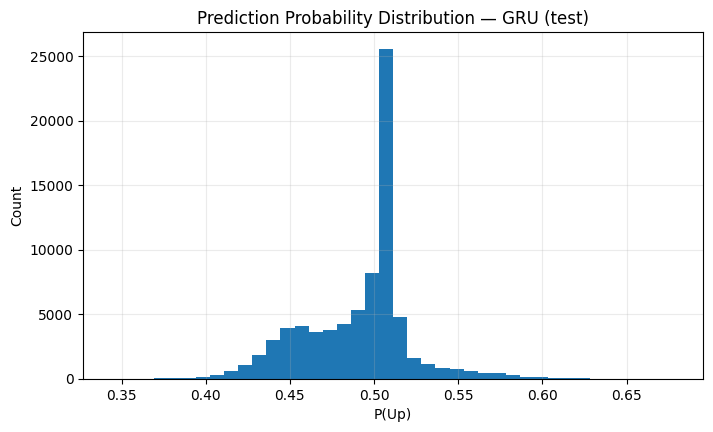


Confidence-filtered performance:


,top_fraction,n_samples,accuracy,bal_acc,macro_f1,avg_confidence
0,0.1,7708,0.546834,0.533450,0.504747,0.073562
1,0.2,15417,0.539534,0.527353,0.484972,0.062345
2,0.3,23125,0.532627,0.522337,0.478712,0.054109
3,0.5,38542,0.524285,0.520558,0.497113,0.040287
4,1.0,77085,0.515716,0.515835,0.515517,0.023513


Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/best_deep_confidence_curve_GRU_test.png


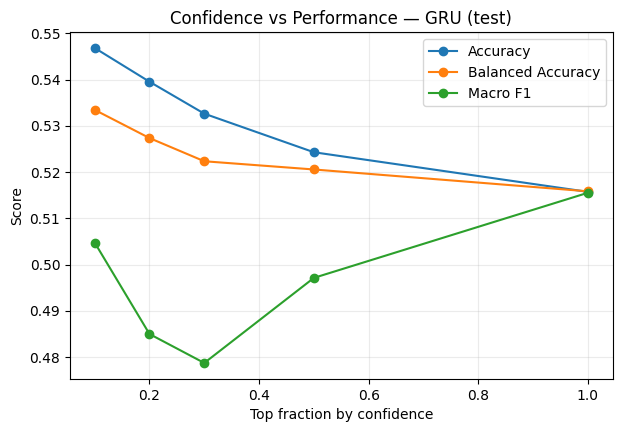

In [ ]:

# Pick the best deep model by fixed-threshold test balanced accuracy and inspect test predictions.
if len(deep_results) > 0:
    best_deep = sorted(deep_results, key=lambda r: (r['bal_acc'], r['macro_f1'], r['accuracy']), reverse=True)[0]
    best_model = best_deep['trained_model']
    best_name = best_deep['model']
    best_threshold = float(best_deep['threshold'])

    print('Best deep model:', best_name)
    print('Fixed threshold:', best_threshold)
    print({k: best_deep[k] for k in ['accuracy', 'bal_acc', 'macro_f1', 'weighted_f1', 'best_epoch', 'best_val_loss']})

    best_metrics, deep_confidence_df, deep_cm_df = run_direction_diagnostics(
        best_model,
        test_loader,
        threshold=best_threshold,
        model_name=best_name,
        split_name="test",
        save_prefix="best_deep"
    )
else:
    print('No deep model results yet.')


Best deep model confidence-filter sweep:


,lower,upper,n_trades,coverage,accuracy,bal_acc,macro_f1,weighted_f1,pred_down,pred_up
0,0.45,0.55,12073,0.156619,0.541622,0.530068,0.491306,0.497600,9596,2477
1,0.40,0.60,448,0.005812,0.575893,0.576595,0.575884,0.575825,215,233
2,0.35,0.65,9,0.000117,0.555556,0.666667,0.550000,0.533333,2,7
3,0.30,0.70,0,0.000000,NaN,NaN,NaN,NaN,0,0
4,0.25,0.75,0,0.000000,NaN,NaN,NaN,NaN,0,0
5,0.20,0.80,0,0.000000,NaN,NaN,NaN,NaN,0,0
6,0.15,0.85,0,0.000000,NaN,NaN,NaN,NaN,0,0


Best deep confidence-filter row:
{'lower': 0.4, 'upper': 0.6, 'n_trades': 448.0, 'coverage': 0.005811766232081468, 'accuracy': 0.5758928571428571, 'bal_acc': 0.5765954475631895, 'macro_f1': 0.5758844045839562, 'weighted_f1': 0.5758252366716492, 'pred_down': 215.0, 'pred_up': 233.0}
Saved figure: /teamspace/studios/this_studio/btc_research/reports/deep_confidence_filter_tradeoff_GRU.png


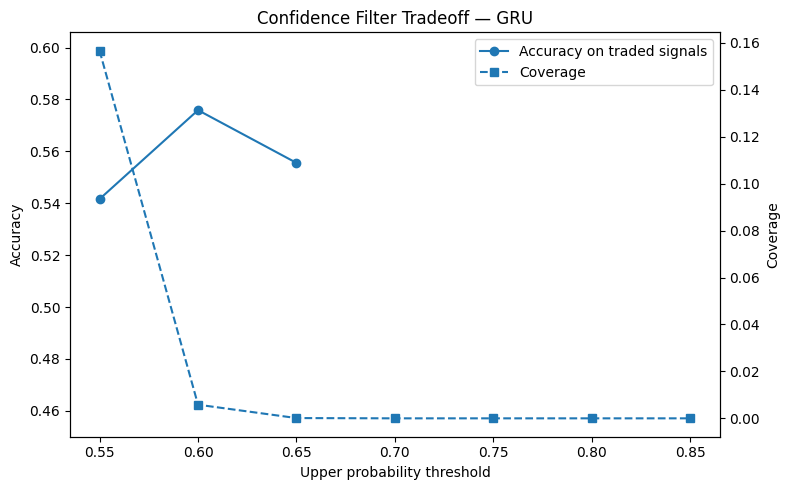

In [ ]:
# Confidence filtering for the best single-task deep model.
if len(deep_results) > 0:
    y_true_deep, y_pred_deep, y_proba_deep = collect_direction_outputs(best_model, test_loader)

    deep_cf_df = confidence_filter_sweep(
        y_true=y_true_deep,
        proba_up=y_proba_deep,
        upper_grid=(0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85),
    )
    print("Best deep model confidence-filter sweep:")
    display(deep_cf_df)

    if len(deep_cf_df) > 0:
        deep_cf_best = deep_cf_df.sort_values(
            ["accuracy", "coverage"], ascending=[False, False]
        ).iloc[0].to_dict()
        print("Best deep confidence-filter row:")
        print(deep_cf_best)

        plot_confidence_filter_tradeoff(
            deep_cf_df,
            title=f"Confidence Filter Tradeoff — {best_name}",
            save_name=f"deep_confidence_filter_tradeoff_{best_name}",
        )
    else:
        print("No deep confidence-filter trades found for the selected grid.")
else:
    print("No deep model results yet.")

## 18. Integrated Multitask Direction + Regime + Return Pipeline

The next research step is to reuse the same sequence dataset and train multitask models with three heads:

- binary direction classification
- 3-class regime classification
- future return regression

The shared encoder is encouraged to learn better market representations by jointly modeling direction, state, and magnitude.


In [ ]:
xb, yb_dir, yb_reg, yb_ret = next(iter(train_loader))

print("xb shape:", xb.shape)
print("yb_dir shape:", yb_dir.shape)
print("yb_reg shape:", yb_reg.shape)
print("yb_ret shape:", yb_ret.shape)

print("seq_len:", xb.shape[1])
print("features:", xb.shape[2])

print("direction label distribution:", torch.bincount(yb_dir, minlength=NUM_DIRECTION_CLASSES))
print("regime label distribution:", torch.bincount(yb_reg, minlength=3))
assert xb.ndim == 3, f"Expected (batch, seq_len, features), got {tuple(xb.shape)}"

print("Train direction distribution:", pd.Series(ytr_dir).value_counts(normalize=True).sort_index().round(4).to_dict())
print("Train regime distribution   :", pd.Series(ytr_reg).value_counts(normalize=True).sort_index().round(4).to_dict())


xb shape: torch.Size([64, 240, 56])
yb_dir shape: torch.Size([64])
yb_reg shape: torch.Size([64])
yb_ret shape: torch.Size([64])
seq_len: 240
features: 56
direction label distribution: tensor([33, 31])
regime label distribution: tensor([23, 19, 22])
Train direction distribution: {0: 0.4937, 1: 0.5063}
Train regime distribution   : {0: 0.3333, 1: 0.3334, 2: 0.3333}



Launching MultiTaskCNN1D | epochs=20 | lr=5.00e-04 | wd=7.00e-04
[MultiTaskCNN1D] dir_loss=cross_entropy class_weight=[1.0137568712234497, 0.9862431287765503]
[MultiTaskCNN1D] regime_loss=cross_entropy class_weight=[0.9998249411582947, 1.0000250339508057, 1.0001500844955444]

Training multitask model: MultiTaskCNN1D
[MultiTaskCNN1D] Epoch 01 | TrainLoss 0.7315 | TrainAcc 0.5532 | TrainBalAcc 0.5538 | ValLoss 0.7363 | ValAcc 0.5250 | ValBalAcc 0.5241 | ValMacroF1 0.5138 | ValRegAcc 0.9030 | ValRetMAE 0.0017 | LR 1.16e-04
[MultiTaskCNN1D] Epoch 02 | TrainLoss 0.7197 | TrainAcc 0.5493 | TrainBalAcc 0.5514 | ValLoss 0.7216 | ValAcc 0.5246 | ValBalAcc 0.5229 | ValMacroF1 0.4821 | ValRegAcc 0.9351 | ValRetMAE 0.0017 | LR 2.75e-04
[MultiTaskCNN1D] Epoch 03 | TrainLoss 0.7130 | TrainAcc 0.5574 | TrainBalAcc 0.5574 | ValLoss 0.7173 | ValAcc 0.5295 | ValBalAcc 0.5291 | ValMacroF1 0.5277 | ValRegAcc 0.9432 | ValRetMAE 0.0015 | LR 4.34e-04
[MultiTaskCNN1D] Epoch 04 | TrainLoss 0.7102 | TrainAcc 0

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[MultiTaskCNNTransformerAttention] Epoch 01 | TrainLoss 0.7228 | TrainAcc 0.5522 | TrainBalAcc 0.5528 | ValLoss 0.7303 | ValAcc 0.5229 | ValBalAcc 0.5226 | ValMacroF1 0.5217 | ValRegAcc 0.9172 | ValRetMAE 0.0020 | LR 9.27e-05
[MultiTaskCNNTransformerAttention] Epoch 02 | TrainLoss 0.7167 | TrainAcc 0.5563 | TrainBalAcc 0.5572 | ValLoss 0.7236 | ValAcc 0.5244 | ValBalAcc 0.5238 | ValMacroF1 0.5198 | ValRegAcc 0.9348 | ValRetMAE 0.0014 | LR 2.20e-04
[MultiTaskCNNTransformerAttention] Epoch 03 | TrainLoss 0.7105 | TrainAcc 0.5595 | TrainBalAcc 0.5584 | ValLoss 0.7244 | ValAcc 0.5248 | ValBalAcc 0.5255 | ValMacroF1 0.5198 | ValRegAcc 0.9309 | ValRetMAE 0.0015 | LR 3.47e-04
[MultiTaskCNNTransformerAttention] Epoch 04 | TrainLoss 0.7076 | TrainAcc 0.5621 | TrainBalAcc 0.5625 | ValLoss 0.7215 | ValAcc 0.5260 | ValBalAcc 0.5260 | ValMacroF1 0.5259 | ValRegAcc 0.9294 | ValRetMAE 0.0014 | LR 4.00e-04
[MultiTaskCNNTransformerAttention] Epoch 05 | TrainLoss 0.7057 | TrainAcc 0.5645 | TrainBalAcc 0

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[MultiTaskTransformerEncoder] Epoch 01 | TrainLoss 0.7273 | TrainAcc 0.5518 | TrainBalAcc 0.5521 | ValLoss 0.7325 | ValAcc 0.5253 | ValBalAcc 0.5254 | ValMacroF1 0.5250 | ValRegAcc 0.9123 | ValRetMAE 0.0025 | LR 6.95e-05
[MultiTaskTransformerEncoder] Epoch 02 | TrainLoss 0.7198 | TrainAcc 0.5561 | TrainBalAcc 0.5553 | ValLoss 0.7297 | ValAcc 0.5226 | ValBalAcc 0.5231 | ValMacroF1 0.5190 | ValRegAcc 0.9180 | ValRetMAE 0.0014 | LR 1.65e-04
[MultiTaskTransformerEncoder] Epoch 03 | TrainLoss 0.7154 | TrainAcc 0.5448 | TrainBalAcc 0.5455 | ValLoss 0.7190 | ValAcc 0.5121 | ValBalAcc 0.5113 | ValMacroF1 0.5016 | ValRegAcc 0.9440 | ValRetMAE 0.0015 | LR 2.60e-04
[MultiTaskTransformerEncoder] Epoch 04 | TrainLoss 0.7114 | TrainAcc 0.5583 | TrainBalAcc 0.5568 | ValLoss 0.7247 | ValAcc 0.5181 | ValBalAcc 0.5195 | ValMacroF1 0.4943 | ValRegAcc 0.9371 | ValRetMAE 0.0019 | LR 3.00e-04
[MultiTaskTransformerEncoder] Epoch 05 | TrainLoss 0.7065 | TrainAcc 0.5611 | TrainBalAcc 0.5615 | ValLoss 0.7153 | 

,model,status,accuracy,bal_acc,macro_f1,weighted_f1,brier,ece,regime_acc,regime_macro_f1,return_mae,return_corr,best_epoch,checkpoint,history_csv,threshold,threshold_table_csv
0,MultiTaskCNNTransformerAttention,ok,0.513848,0.514187,0.511921,0.511762,0.250064,0.012995,0.947201,0.947480,0.001587,0.004413,5,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
1,MultiTaskLSTM,ok,0.513939,0.513805,0.513541,0.513613,0.250197,0.013802,0.981670,0.981966,0.001438,0.010563,19,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
2,MultiTaskCNNGRU,ok,0.513965,0.513717,0.512717,0.512845,0.249982,0.009738,0.971395,0.971834,0.001494,0.001321,14,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
3,MultiTaskGRU,ok,0.514147,0.513632,0.509036,0.509295,0.250040,0.011603,0.956788,0.957435,0.001472,0.006117,8,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
4,MultiTaskCNN1D,ok,0.513018,0.512430,0.506346,0.506643,0.250000,0.012113,0.970526,0.971033,0.001449,0.005801,14,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...
5,MultiTaskTransformerEncoder,ok,0.512953,0.512297,0.504662,0.504994,0.250000,0.011969,0.973769,0.974330,0.001442,0.006877,16,/teamspace/studios/this_studio/artifacts/btc_r...,/teamspace/studios/this_studio/artifacts/btc_r...,0.5,/teamspace/studios/this_studio/artifacts/btc_r...



Best multitask model: MultiTaskCNNTransformerAttention
Fixed threshold: 0.5

Test predicted class distribution:
{0: 33499, 1: 43586}

Confusion matrix:


,Pred Down,Pred Up
True Down,17383,21359
True Up,16116,22227



Classification report:
              precision    recall  f1-score   support

           0     0.5189    0.4487    0.4813     38742
           1     0.5100    0.5797    0.5426     38343

    accuracy                         0.5138     77085
   macro avg     0.5144    0.5142    0.5119     77085
weighted avg     0.5145    0.5138    0.5118     77085


Multitask calibration metrics:
{'brier': 0.25006434321403503, 'ece': 0.012995091112174822}
Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/multitask_probability_histogram_MultiTaskCNNTransformerAttention_test.png


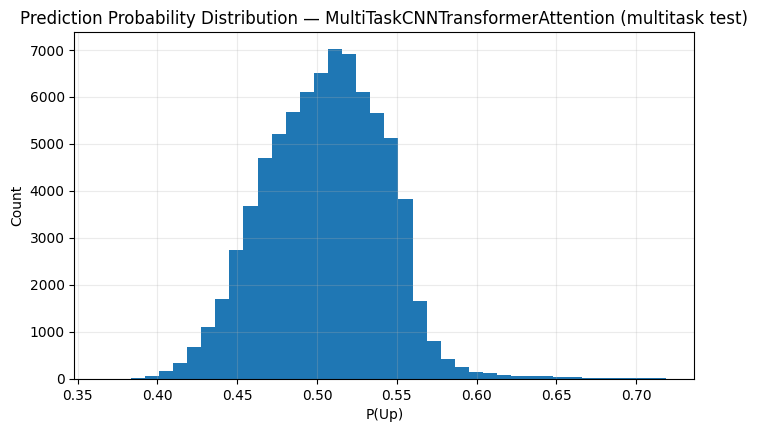


Multitask confidence-filtered performance:


,top_fraction,n_samples,accuracy,bal_acc,macro_f1,avg_confidence
0,0.1,7708,0.537364,0.537662,0.535393,0.074884
1,0.2,15417,0.530713,0.530289,0.525060,0.063766
2,0.3,23125,0.529730,0.529559,0.524240,0.057196
3,0.5,38542,0.524986,0.525231,0.521313,0.047710
4,1.0,77085,0.513848,0.514187,0.511921,0.030530


Saved figure: /teamspace/studios/this_studio/artifacts/btc_research/reports/multitask_confidence_curve_MultiTaskCNNTransformerAttention_test.png


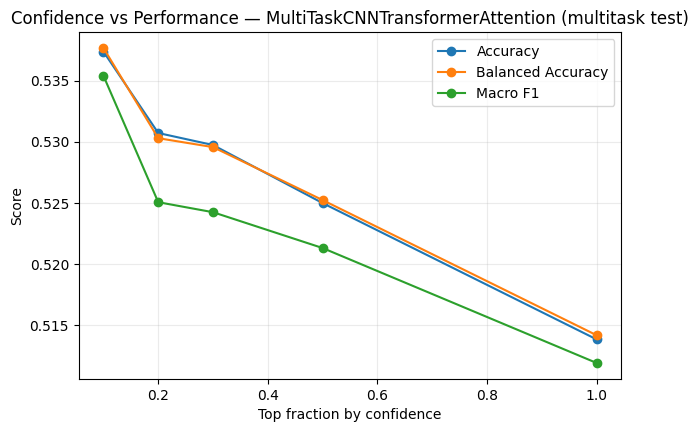


Additional multitask test metrics:
{'regime_acc': 0.9472011415969385, 'regime_macro_f1': 0.9474800561699221, 'return_mae': 0.0015873038209974766, 'return_corr': 0.004412534172688999, 'loss': 0.7157625262173379, 'dir_loss': 0.6934890203950811, 'reg_loss': 0.11136614991607013, 'ret_loss': 2.754827601382739e-06}

Single-task vs multitask direction comparison:


,model,accuracy,bal_acc,macro_f1,weighted_f1,task_type
0,GRU,0.515716,0.515835,0.515517,0.515466,single_task
1,MultiTaskCNNTransformerAttention,0.513848,0.514187,0.511921,0.511762,multitask
2,CNN-GRU,0.514328,0.513917,0.511024,0.511232,single_task
3,MultiTaskLSTM,0.513939,0.513805,0.513541,0.513613,multitask
4,MultiTaskCNNGRU,0.513965,0.513717,0.512717,0.512845,multitask
5,MultiTaskGRU,0.514147,0.513632,0.509036,0.509295,multitask
6,TransformerEncoder,0.512668,0.512725,0.512633,0.512612,single_task
7,MultiTaskCNN1D,0.513018,0.512430,0.506346,0.506643,multitask
8,MultiTaskTransformerEncoder,0.512953,0.512297,0.504662,0.504994,multitask
9,MLP(sequence),0.512681,0.512213,0.508428,0.508665,single_task


In [ ]:
# ------------------------------------------------------------
# Integrated multitask model zoo:
# shared encoder + three heads
# - binary direction classification
# - 3-class regime classification
# - future return regression
#
# The multitask versions below reuse the upgraded backbones from the
# single-task zoo so the comparison is fair.
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd


class MultiTaskSequenceModel(nn.Module):
    def __init__(self, backbone, backbone_dim, dropout=0.20, use_cls_token=False):
        super().__init__()
        self.backbone = backbone
        self.pool = EnhancedTemporalPool(backbone_dim, dropout=dropout * 0.5)
        self.use_cls_token = bool(use_cls_token)
        shared_in = self.pool.out_dim + (backbone_dim if self.use_cls_token else 0)

        self.shared = nn.Sequential(
            nn.LayerNorm(shared_in),
            nn.Linear(shared_in, 192),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # First predict regime, then feed a learned regime-aware context into the
        # direction / return heads.
        self.regime_head = nn.Linear(96, 3)
        self.regime_embed = nn.Linear(3, 24)

        fused_dim = 96 + 24
        self.direction_head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 96),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(96, NUM_DIRECTION_CLASSES),
        )
        self.return_head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 96),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(96, 1),
        )

    def forward(self, x):
        h = self.backbone(x)
        if self.use_cls_token:
            cls_vec = h[:, 0, :]
            seq = h[:, 1:, :]
            pooled, _ = self.pool(seq)
            z = self.shared(torch.cat([cls_vec, pooled], dim=1))
        else:
            pooled, _ = self.pool(h)
            z = self.shared(pooled)

        regime_logits = self.regime_head(z)
        regime_probs = torch.softmax(regime_logits, dim=1)
        regime_context = self.regime_embed(regime_probs)
        fused = torch.cat([z, regime_context], dim=1)

        return {
            'direction_logits': self.direction_head(fused),
            'regime_logits': regime_logits,
            'return_pred': self.return_head(fused).squeeze(-1),
        }


class MultiTaskGRU(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True):
        super().__init__()
        backbone = ResidualGRUBackbone(
            input_dim=input_dim,
            hidden=hidden,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            proj_dim=96,
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class MultiTaskLSTM(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.20, bidirectional=True):
        super().__init__()
        backbone = ResidualLSTMBackbone(
            input_dim=input_dim,
            hidden=hidden,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            proj_dim=96,
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class MultiTaskCNNGRU(nn.Module):
    def __init__(self, input_dim, hidden=96, dropout=0.20):
        super().__init__()
        backbone = CNNGRUBackbone(
            input_dim=input_dim,
            conv_channels=96,
            hidden=hidden,
            num_layers=1,
            dropout=dropout,
            bidirectional=True,
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout)

    def forward(self, x):
        return self.model(x)


class MultiTaskTransformerEncoder(nn.Module):
    def __init__(self, input_dim, d_model=96, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.15, local_window=32):
        super().__init__()
        backbone = LocalTransformerBackbone(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            local_window=local_window,
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout, use_cls_token=True)

    def forward(self, x):
        return self.model(x)


class MultiTaskCNNTransformerAttention(nn.Module):
    def __init__(self, input_dim, d_model=96, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.15, local_window=32):
        super().__init__()
        backbone = CNNTransformerHybridBackbone(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            local_window=local_window,
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout, use_cls_token=True)

    def forward(self, x):
        return self.model(x)


class MultiTaskCNN1D(nn.Module):
    def __init__(self, input_dim, dropout=0.18):
        super().__init__()
        backbone = TCNBackbone(
            input_dim=input_dim,
            channels=96,
            kernel_size=3,
            dilations=(1, 2, 4, 8),
            dropout=0.12
        )
        self.model = MultiTaskSequenceModel(backbone, backbone.output_dim, dropout=dropout)

    def forward(self, x):
        return self.model(x)


def multitask_loss_fn(
    outputs,
    y_dir,
    y_reg,
    y_ret,
    dir_criterion,
    regime_criterion,
    regime_weight=MULTITASK_REG_W,
    return_weight=MULTITASK_RET_W,
    dir_weight=MULTITASK_DIR_W,
):
    dir_loss = dir_criterion(outputs['direction_logits'], y_dir)
    reg_loss = regime_criterion(outputs['regime_logits'], y_reg)
    ret_loss = F.smooth_l1_loss(outputs['return_pred'], y_ret)
    total = dir_weight * dir_loss + regime_weight * reg_loss + return_weight * ret_loss
    return total, dir_loss, reg_loss, ret_loss


def evaluate_multitask_model(
    model,
    loader,
    dir_criterion,
    regime_criterion,
    dir_threshold=0.5,
):
    model.eval()

    total_losses = []
    dir_losses = []
    reg_losses = []
    ret_losses = []

    y_dir_true, y_reg_true, y_ret_true = [], [], []
    y_dir_prob_up, y_reg_pred, y_ret_pred = [], [], []

    with torch.no_grad():
        for xb, yb_dir, yb_reg, yb_ret in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb_dir = yb_dir.to(DEVICE, non_blocking=True)
            yb_reg = yb_reg.to(DEVICE, non_blocking=True)
            yb_ret = yb_ret.to(DEVICE, non_blocking=True)

            outputs = model(xb)

            total_loss, dir_loss, reg_loss, ret_loss = multitask_loss_fn(
                outputs,
                yb_dir,
                yb_reg,
                yb_ret,
                dir_criterion,
                regime_criterion,
            )

            dir_prob = torch.softmax(outputs['direction_logits'], dim=1)[:, 1]
            reg_pred = outputs['regime_logits'].argmax(dim=1)
            ret_pred = outputs['return_pred']

            total_losses.append(float(total_loss.item()))
            dir_losses.append(float(dir_loss.item()))
            reg_losses.append(float(reg_loss.item()))
            ret_losses.append(float(ret_loss.item()))

            y_dir_true.append(yb_dir.detach().cpu().numpy())
            y_reg_true.append(yb_reg.detach().cpu().numpy())
            y_ret_true.append(yb_ret.detach().cpu().numpy())
            y_dir_prob_up.append(dir_prob.detach().cpu().numpy())
            y_reg_pred.append(reg_pred.detach().cpu().numpy())
            y_ret_pred.append(ret_pred.detach().cpu().numpy())

    y_dir_true = np.concatenate(y_dir_true)
    y_reg_true = np.concatenate(y_reg_true)
    y_ret_true = np.concatenate(y_ret_true)
    y_dir_prob_up = np.concatenate(y_dir_prob_up)
    y_reg_pred = np.concatenate(y_reg_pred)
    y_ret_pred = np.concatenate(y_ret_pred)

    y_dir_pred = (y_dir_prob_up >= dir_threshold).astype(np.int64)

    return {
        'loss': float(np.mean(total_losses)),
        'dir_loss': float(np.mean(dir_losses)),
        'reg_loss': float(np.mean(reg_losses)),
        'ret_loss': float(np.mean(ret_losses)),
        'accuracy': float(accuracy_score(y_dir_true, y_dir_pred)),
        'bal_acc': float(balanced_accuracy_score(y_dir_true, y_dir_pred)),
        'macro_f1': float(f1_score(y_dir_true, y_dir_pred, average='macro')),
        'weighted_f1': float(f1_score(y_dir_true, y_dir_pred, average='weighted')),
        'brier': float(binary_brier_score(y_dir_true, y_dir_prob_up)),
        'ece': float(expected_calibration_error(y_dir_true, y_dir_prob_up)),
        'regime_acc': float(accuracy_score(y_reg_true, y_reg_pred)),
        'regime_macro_f1': float(f1_score(y_reg_true, y_reg_pred, average='macro')),
        'return_mae': float(mean_absolute_error(y_ret_true, y_ret_pred)),
        'return_corr': float(np.corrcoef(y_ret_true, y_ret_pred)[0, 1]) if len(y_ret_true) > 1 else np.nan,
        'y_dir_true': y_dir_true,
        'y_reg_true': y_reg_true,
        'y_ret_true': y_ret_true,
        'y_dir_prob_up': y_dir_prob_up,
        'y_reg_pred': y_reg_pred,
        'y_ret_pred': y_ret_pred,
    }


def train_multitask_model(
    model_name,
    model,
    train_loader,
    val_loader,
    y_train_window,
    epochs=8,
    lr=4e-4,
    weight_decay=7e-4,
    patience=5,
    grad_clip=1.0,
    pct_start=0.2
):
    model = model.to(DEVICE)

    dir_criterion, dir_class_weight_vec = build_direction_criterion(y_train_window)
    regime_criterion = nn.CrossEntropyLoss(weight=regime_class_weight_vec.to(DEVICE))

    print(f"[{model_name}] dir_loss={LOSS_NAME} class_weight={dir_class_weight_vec.detach().cpu().tolist()}")
    print(f"[{model_name}] regime_loss=cross_entropy class_weight={regime_class_weight_vec.detach().cpu().tolist()}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=pct_start,
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=50.0,
    )
    scaler = torch.amp.GradScaler(device='cuda', enabled=(USE_AMP and DEVICE == 'cuda'))

    best_state = None
    best_epoch = -1
    best_threshold = 0.5
    best_thr_table = pd.DataFrame({'threshold': [float(FIXED_THRESHOLD)]})
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    wait = 0
    history = []

    print('\n' + '=' * 90)
    print(f'Training multitask model: {model_name}')
    print('=' * 90)

    for epoch in range(1, epochs + 1):
        model.train()
        train_total_losses, train_dir_losses, train_reg_losses, train_ret_losses = [], [], [], []

        for xb, yb_dir, yb_reg, yb_ret in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb_dir = yb_dir.to(DEVICE, non_blocking=True)
            yb_reg = yb_reg.to(DEVICE, non_blocking=True)
            yb_ret = yb_ret.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type='cuda', enabled=(USE_AMP and DEVICE == 'cuda')):
                outputs = model(xb)
                total_loss, dir_loss, reg_loss, ret_loss = multitask_loss_fn(
                    outputs,
                    yb_dir,
                    yb_reg,
                    yb_ret,
                    dir_criterion,
                    regime_criterion,
                )

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_total_losses.append(float(total_loss.item()))
            train_dir_losses.append(float(dir_loss.item()))
            train_reg_losses.append(float(reg_loss.item()))
            train_ret_losses.append(float(ret_loss.item()))

        train_metrics = evaluate_multitask_model(
            model,
            train_loader,
            dir_criterion=dir_criterion,
            regime_criterion=regime_criterion,
            dir_threshold=float(FIXED_THRESHOLD),
        )
        val_metrics = evaluate_multitask_model(
            model,
            val_loader,
            dir_criterion=dir_criterion,
            regime_criterion=regime_criterion,
            dir_threshold=float(FIXED_THRESHOLD),
        )

        current_lr = optimizer.param_groups[0]['lr']
        score = (
            float(val_metrics['bal_acc']),
            float(val_metrics['macro_f1']),
            float(val_metrics['regime_acc']),
            -float(val_metrics['return_mae']),
            -float(val_metrics['ece']),
        )

        history.append({
            'epoch': epoch,

            'train_loss': float(train_metrics['loss']),
            'train_dir_loss': float(train_metrics['dir_loss']),
            'train_reg_loss': float(train_metrics['reg_loss']),
            'train_ret_loss': float(train_metrics['ret_loss']),
            'train_acc': float(train_metrics['accuracy']),
            'train_bal_acc': float(train_metrics['bal_acc']),
            'train_macro_f1': float(train_metrics['macro_f1']),
            'train_regime_acc': float(train_metrics['regime_acc']),
            'train_return_mae': float(train_metrics['return_mae']),
            'train_brier': float(train_metrics['brier']),
            'train_ece': float(train_metrics['ece']),

            'val_loss': float(val_metrics['loss']),
            'val_dir_loss': float(val_metrics['dir_loss']),
            'val_reg_loss': float(val_metrics['reg_loss']),
            'val_ret_loss': float(val_metrics['ret_loss']),
            'val_threshold': float(FIXED_THRESHOLD),
            'val_acc': float(val_metrics['accuracy']),
            'val_bal_acc': float(val_metrics['bal_acc']),
            'val_macro_f1': float(val_metrics['macro_f1']),
            'val_regime_acc': float(val_metrics['regime_acc']),
            'val_return_mae': float(val_metrics['return_mae']),
            'val_brier': float(val_metrics['brier']),
            'val_ece': float(val_metrics['ece']),
            'lr': current_lr,
        })

        print(
            f"[{model_name}] Epoch {epoch:02d} | "
            f"TrainLoss {history[-1]['train_loss']:.4f} | "
            f"TrainAcc {history[-1]['train_acc']:.4f} | "
            f"TrainBalAcc {history[-1]['train_bal_acc']:.4f} | "
            f"ValLoss {history[-1]['val_loss']:.4f} | "
            f"ValAcc {history[-1]['val_acc']:.4f} | "
            f"ValBalAcc {history[-1]['val_bal_acc']:.4f} | "
            f"ValMacroF1 {history[-1]['val_macro_f1']:.4f} | "
            f"ValRegAcc {history[-1]['val_regime_acc']:.4f} | "
            f"ValRetMAE {history[-1]['val_return_mae']:.4f} | "
            f"LR {current_lr:.2e}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_threshold = float(FIXED_THRESHOLD)
            best_thr_table = pd.DataFrame({'threshold': [float(FIXED_THRESHOLD)]})
        else:
            wait += 1
            if wait >= patience:
                print(f'[{model_name}] Early stopping.')
                break

    history_df = pd.DataFrame(history)
    ckpt_path = ARTIFACT_ROOT / 'checkpoints' / f"{model_name.replace('/', '_')}_multitask.pt"

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, ckpt_path)

    return history_df, model, ckpt_path, best_epoch, best_threshold, best_thr_table


def run_multitask_experiment(model_name, model, epochs=8, lr=4e-4, weight_decay=7e-4, grad_clip=1.0):
    hist, model, ckpt_path, best_epoch, best_threshold, best_thr_table = train_multitask_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        y_train_window=ytr_dir[train_ds.ends],
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        patience=6 if DEV_MODE else 8,
        grad_clip=grad_clip,
        pct_start=0.20,
    )

    if len(hist) == 0:
        return {
            'model': model_name,
            'status': 'failed',
            'history': hist,
            'trained_model': model,
            'accuracy': np.nan,
            'bal_acc': np.nan,
            'macro_f1': np.nan,
            'weighted_f1': np.nan,
            'brier': np.nan,
            'ece': np.nan,
            'regime_acc': np.nan,
            'regime_macro_f1': np.nan,
            'return_mae': np.nan,
            'return_corr': np.nan,
            'best_epoch': -1,
            'checkpoint': None,
            'history_csv': None,
            'threshold': np.nan,
            'threshold_table_csv': None,
        }

    dir_criterion, _ = build_direction_criterion(ytr_dir[train_ds.ends])
    regime_criterion = nn.CrossEntropyLoss(weight=regime_class_weight_vec.to(DEVICE))

    test_metrics = evaluate_multitask_model(
        model,
        test_loader,
        dir_criterion=dir_criterion,
        regime_criterion=regime_criterion,
        dir_threshold=float(FIXED_THRESHOLD),
    )

    hist_path = ARTIFACT_ROOT / 'results' / f"{model_name.replace('/', '_')}_multitask_history.csv"
    hist.to_csv(hist_path, index=False)

    thr_path = ARTIFACT_ROOT / 'results' / f"{model_name.replace('/', '_')}_multitask_threshold_table.csv"
    best_thr_table.to_csv(thr_path, index=False)

    return {
        'model': model_name,
        'status': 'ok',
        'history': hist,
        'trained_model': model,
        'accuracy': float(test_metrics['accuracy']),
        'bal_acc': float(test_metrics['bal_acc']),
        'macro_f1': float(test_metrics['macro_f1']),
        'weighted_f1': float(test_metrics['weighted_f1']),
        'brier': float(test_metrics['brier']),
        'ece': float(test_metrics['ece']),
        'regime_acc': float(test_metrics['regime_acc']),
        'regime_macro_f1': float(test_metrics['regime_macro_f1']),
        'return_mae': float(test_metrics['return_mae']),
        'return_corr': float(test_metrics['return_corr']),
        'best_epoch': int(best_epoch),
        'checkpoint': str(ckpt_path),
        'history_csv': str(hist_path),
        'threshold': float(FIXED_THRESHOLD),
        'threshold_table_csv': str(thr_path),
    }


multitask_results = []

MULTITASK_EXPERIMENTS = [
    {
        'name': 'MultiTaskCNN1D',
        'builder': lambda: MultiTaskCNN1D(input_dim=INPUT_SIZE, dropout=0.18),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 5e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'MultiTaskGRU',
        'builder': lambda: MultiTaskGRU(input_dim=INPUT_SIZE, hidden=96, num_layers=2, dropout=0.20, bidirectional=True),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 4e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'MultiTaskLSTM',
        'builder': lambda: MultiTaskLSTM(input_dim=INPUT_SIZE, hidden=96, num_layers=2, dropout=0.20, bidirectional=True),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 4e-4,
        'weight_decay': 7e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'MultiTaskCNNGRU',
        'builder': lambda: MultiTaskCNNGRU(input_dim=INPUT_SIZE, hidden=96, dropout=0.20),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 4e-4,
        'weight_decay': 8e-4,
        'grad_clip': 1.0,
    },
    {
        'name': 'MultiTaskCNNTransformerAttention',
        'builder': lambda: MultiTaskCNNTransformerAttention(
            input_dim=INPUT_SIZE,
            d_model=96,
            nhead=4,
            num_layers=2,
            dim_feedforward=256,
            dropout=0.15,
            local_window=max(24, HORIZON * 3),
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 4e-4,
        'weight_decay': 8e-4,
        'grad_clip': 0.8,
    },
    {
        'name': 'MultiTaskTransformerEncoder',
        'builder': lambda: MultiTaskTransformerEncoder(
            input_dim=INPUT_SIZE,
            d_model=96,
            nhead=4,
            num_layers=3,
            dim_feedforward=256,
            dropout=0.15,
            local_window=max(24, HORIZON * 3),
        ),
        'epochs': min(14, DEFAULT_EPOCHS) if DEV_MODE else min(20, DEFAULT_EPOCHS),
        'lr': 3e-4,
        'weight_decay': 8e-4,
        'grad_clip': 0.8,
    },
]

for cfg in MULTITASK_EXPERIMENTS:
    try:
        print('\n' + '=' * 90)
        print(
            f"Launching {cfg['name']} | "
            f"epochs={cfg['epochs']} | "
            f"lr={cfg['lr']:.2e} | "
            f"wd={cfg['weight_decay']:.2e}"
        )
        print('=' * 90)

        res = run_multitask_experiment(
            cfg['name'],
            cfg['builder'](),
            epochs=cfg['epochs'],
            lr=cfg['lr'],
            weight_decay=cfg['weight_decay'],
            grad_clip=cfg.get('grad_clip', 1.0),
        )
        multitask_results.append(res)

    except RuntimeError as e:
        print(f"[{cfg['name']}] failed with RuntimeError: {e}")
        if 'out of memory' in str(e).lower() and torch.cuda.is_available():
            torch.cuda.empty_cache()

        multitask_results.append({
            'model': cfg['name'],
            'status': 'failed',
            'history': pd.DataFrame(),
            'trained_model': None,
            'accuracy': np.nan,
            'bal_acc': np.nan,
            'macro_f1': np.nan,
            'weighted_f1': np.nan,
            'brier': np.nan,
            'ece': np.nan,
            'regime_acc': np.nan,
            'regime_macro_f1': np.nan,
            'return_mae': np.nan,
            'return_corr': np.nan,
            'best_epoch': -1,
            'checkpoint': None,
            'history_csv': None,
            'threshold': np.nan,
            'threshold_table_csv': None,
        })

print('Finished multitask experiments:', [r['model'] for r in multitask_results])

multitask_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['history', 'trained_model']}
    for r in multitask_results
]).sort_values(['bal_acc', 'macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)

print('\nMultitask leaderboard:')
display(multitask_results_df)

if len(multitask_results) > 0 and multitask_results_df.shape[0] > 0:
    best_mt_name = multitask_results_df.iloc[0]['model']
    best_mt = next(r for r in multitask_results if r['model'] == best_mt_name)
    best_mt_model = best_mt['trained_model']
    best_mt_threshold = float(best_mt['threshold'])

    print('\nBest multitask model:', best_mt_name)
    print('Fixed threshold:', best_mt_threshold)

    dir_criterion, _ = build_direction_criterion(ytr_dir[train_ds.ends])
    regime_criterion = nn.CrossEntropyLoss(weight=regime_class_weight_vec.to(DEVICE))

    mt_test = evaluate_multitask_model(
        best_mt_model,
        test_loader,
        dir_criterion=dir_criterion,
        regime_criterion=regime_criterion,
        dir_threshold=best_mt_threshold,
    )

    y_true = mt_test['y_dir_true']
    y_pred = (mt_test['y_dir_prob_up'] >= best_mt_threshold).astype(np.int64)
    y_proba_up = mt_test['y_dir_prob_up']

    print('\nTest predicted class distribution:')
    print(pd.Series(y_pred).value_counts().sort_index().to_dict())

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=['True Down', 'True Up'], columns=['Pred Down', 'Pred Up'])
    print('\nConfusion matrix:')
    display(cm_df)

    print('\nClassification report:')
    print(classification_report(y_true, y_pred, digits=4))

    print('\nMultitask calibration metrics:')
    print({'brier': float(mt_test['brier']), 'ece': float(mt_test['ece'])})

    plot_probability_histogram(
        y_proba_up,
        title=f'Prediction Probability Distribution — {best_mt_name} (multitask test)',
        save_name=f'multitask_probability_histogram_{best_mt_name}_test'
    )

    mt_conf_df = confidence_performance_table(y_true, y_proba_up)
    print('\nMultitask confidence-filtered performance:')
    display(mt_conf_df)

    plot_confidence_curve(
        mt_conf_df,
        title=f'Confidence vs Performance — {best_mt_name} (multitask test)',
        save_name=f'multitask_confidence_curve_{best_mt_name}_test'
    )

    print('\nAdditional multitask test metrics:')
    print({
        'regime_acc': float(mt_test['regime_acc']),
        'regime_macro_f1': float(mt_test['regime_macro_f1']),
        'return_mae': float(mt_test['return_mae']),
        'return_corr': float(mt_test['return_corr']),
        'loss': float(mt_test['loss']),
        'dir_loss': float(mt_test['dir_loss']),
        'reg_loss': float(mt_test['reg_loss']),
        'ret_loss': float(mt_test['ret_loss']),
    })

    multitask_comparison_df = pd.concat([
        deep_results_df[['model', 'accuracy', 'bal_acc', 'macro_f1', 'weighted_f1']].assign(task_type='single_task'),
        multitask_results_df[['model', 'accuracy', 'bal_acc', 'macro_f1', 'weighted_f1']].assign(task_type='multitask'),
    ], ignore_index=True).sort_values(['bal_acc', 'macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)

    print('\nSingle-task vs multitask direction comparison:')
    display(multitask_comparison_df)

Best multitask model confidence-filter sweep:


,lower,upper,n_trades,coverage,accuracy,bal_acc,macro_f1,weighted_f1,pred_down,pred_up
0,0.45,0.55,13697,0.177687,0.530116,0.530288,0.525205,0.525124,5444,8253
1,0.40,0.60,645,0.008367,0.525581,0.518884,0.434379,0.438253,69,576
2,0.35,0.65,136,0.001764,0.522059,0.500000,0.342995,0.358127,0,136
3,0.30,0.70,13,0.000169,0.538462,0.500000,0.350000,0.376923,0,13
4,0.25,0.75,0,0.000000,NaN,NaN,NaN,NaN,0,0
5,0.20,0.80,0,0.000000,NaN,NaN,NaN,NaN,0,0
6,0.15,0.85,0,0.000000,NaN,NaN,NaN,NaN,0,0


Best multitask confidence-filter row:
{'lower': 0.30000000000000004, 'upper': 0.7, 'n_trades': 13.0, 'coverage': 0.00016864500227022118, 'accuracy': 0.5384615384615384, 'bal_acc': 0.5, 'macro_f1': 0.35000000000000003, 'weighted_f1': 0.37692307692307697, 'pred_down': 0.0, 'pred_up': 13.0}
Saved figure: /teamspace/studios/this_studio/btc_research/reports/multitask_confidence_filter_tradeoff_MultiTaskCNNTransformerAttention.png


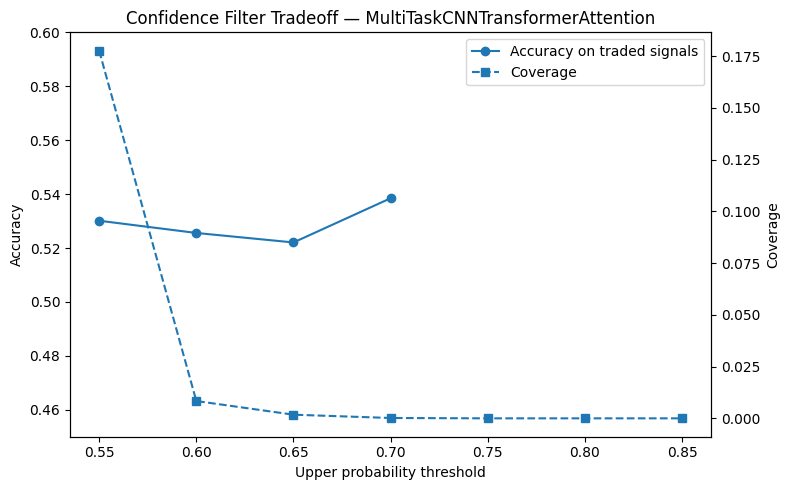

In [ ]:

# Confidence filtering for the best multitask model.
if len(multitask_results) > 0 and multitask_results_df.shape[0] > 0:
    mt_cf_df = confidence_filter_sweep(
        y_true=mt_test['y_dir_true'],
        proba_up=mt_test['y_dir_prob_up'],
        upper_grid=(0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85),
    )
    print("Best multitask model confidence-filter sweep:")
    display(mt_cf_df)

    mt_cf_best = mt_cf_df.sort_values(["accuracy", "coverage"], ascending=[False, False]).iloc[0].to_dict()
    print("Best multitask confidence-filter row:")
    print(mt_cf_best)

    plot_confidence_filter_tradeoff(
        mt_cf_df,
        title=f"Confidence Filter Tradeoff — {best_mt_name}",
        save_name=f"multitask_confidence_filter_tradeoff_{best_mt_name}",
    )
else:
    print("No multitask results yet.")


## Appendix Note

This notebook is organized so that:

- classical baselines use a fixed **0.5** decision threshold for standard classification
- single-task deep models use the same fixed **0.5** threshold
- multitask models extend the same memory-safe sequence pipeline and are also evaluated at **0.5**
- confidence filtering is added as a separate **decision policy** layer:
  - standard classification keeps every prediction
  - confidence filtering keeps only high-confidence predictions using symmetric probability bands such as **0.30 / 0.70**
  - skipped predictions are treated as **no-trade / abstain**


## 19. Event-Style Backtest Across All Models

This section converts each model's **test-set direction predictions** into a simple event-style trading backtest so we can report the financial metrics required by the project:

- cumulative return
- Sharpe ratio
- maximum drawdown
- win rate

Important note: this is an **independent trade sequence backtest**, not a broker-accurate execution simulator.  
Each test prediction is treated as one trade on the corresponding future return target. This is appropriate for model comparison, but it is not the same as a live execution engine with order book slippage, overlapping position accounting, or liquidation logic.


Baseline backtest leaderboard:


,model,n_trades,threshold,cost_per_trade,accuracy,win_rate,avg_trade_return,std_trade_return,cumulative_return,sharpe,max_drawdown,long_rate,short_rate,trade_frequency_per_year_est
0,RandomForest,77085,0.5,0.0,0.515016,0.512772,0.000016,0.002209,1.856113,1.592100,-0.274439,0.341545,0.658455,47990.493665
1,MLP(summary),77085,0.5,0.0,0.509269,0.508594,0.000013,0.002209,1.231590,1.275000,-0.393714,0.687566,0.312434,47990.493665
2,LogisticRegression,77085,0.5,0.0,0.509087,0.507349,0.000010,0.002211,0.733556,0.949348,-0.305563,0.448894,0.551106,47990.493665
3,XGBoost,77085,0.5,0.0,0.510605,0.508348,-0.000002,0.002209,-0.302318,-0.220812,-0.525029,0.338146,0.661854,47990.493665


Single-task deep backtest leaderboard:


,model,n_trades,threshold,cost_per_trade,accuracy,win_rate,avg_trade_return,std_trade_return,cumulative_return,sharpe,max_drawdown,long_rate,short_rate,trade_frequency_per_year_est
0,LSTM,77085,0.5,0.0,0.513005,0.510904,0.000024,0.002210,4.278298,2.382007,-0.232949,0.330713,0.669287,47990.493665
1,GRU,77085,0.5,0.0,0.515716,0.514134,0.000020,0.002209,2.873394,1.984074,-0.257564,0.522877,0.477123,47990.493665
2,CNN-GRU,77085,0.5,0.0,0.514328,0.512356,0.000020,0.002210,2.761708,1.946103,-0.279182,0.420380,0.579620,47990.493665
3,MLP(sequence),77085,0.5,0.0,0.512681,0.510929,0.000015,0.002210,1.555939,1.449144,-0.224107,0.409574,0.590426,47990.493665
4,TransformerEncoder,77085,0.5,0.0,0.512668,0.511176,0.000012,0.002210,1.106677,1.200511,-0.303661,0.511007,0.488993,47990.493665
5,CNN1D,77085,0.5,0.0,0.513161,0.510774,0.000009,0.002210,0.714613,0.935726,-0.358468,0.268651,0.731349,47990.493665
6,CNN-Transformer-Attn,77085,0.5,0.0,0.512927,0.510748,0.000009,0.002209,0.612304,0.856654,-0.317636,0.329493,0.670507,47990.493665


Multitask backtest leaderboard:


,model,n_trades,threshold,cost_per_trade,accuracy,win_rate,avg_trade_return,std_trade_return,cumulative_return,sharpe,max_drawdown,long_rate,short_rate,trade_frequency_per_year_est,regime_acc,return_mae
0,MultiTaskLSTM,77085,0.5,0.0,0.513939,0.512214,0.000014,0.002210,1.385896,1.360488,-0.306554,0.473983,0.526017,47990.493665,0.981670,0.001438
1,MultiTaskTransformerEncoder,77085,0.5,0.0,0.512953,0.510994,0.000013,0.002210,1.292499,1.308943,-0.269261,0.373211,0.626789,47990.493665,0.973769,0.001442
2,MultiTaskCNNTransformerAttention,77085,0.5,0.0,0.513848,0.512382,0.000011,0.002210,0.977221,1.118967,-0.309959,0.565428,0.434572,47990.493665,0.947201,0.001587
3,MultiTaskCNNGRU,77085,0.5,0.0,0.513965,0.512201,0.000008,0.002210,0.493837,0.758372,-0.305163,0.451982,0.548018,47990.493665,0.971395,0.001494
4,MultiTaskGRU,77085,0.5,0.0,0.514147,0.511967,0.000007,0.002209,0.472402,0.739895,-0.296694,0.400558,0.599442,47990.493665,0.956788,0.001472
5,MultiTaskCNN1D,77085,0.5,0.0,0.513018,0.510994,0.000005,0.002210,0.252201,0.531501,-0.311275,0.386327,0.613673,47990.493665,0.970526,0.001449


Combined backtest comparison:


,model,n_trades,threshold,cost_per_trade,accuracy,win_rate,avg_trade_return,std_trade_return,cumulative_return,sharpe,max_drawdown,long_rate,short_rate,trade_frequency_per_year_est,task_type,regime_acc,return_mae
0,LSTM,77085,0.5,0.0,0.513005,0.510904,0.000024,0.002210,4.278298,2.382007,-0.232949,0.330713,0.669287,47990.493665,single_task_deep,NaN,NaN
1,GRU,77085,0.5,0.0,0.515716,0.514134,0.000020,0.002209,2.873394,1.984074,-0.257564,0.522877,0.477123,47990.493665,single_task_deep,NaN,NaN
2,CNN-GRU,77085,0.5,0.0,0.514328,0.512356,0.000020,0.002210,2.761708,1.946103,-0.279182,0.420380,0.579620,47990.493665,single_task_deep,NaN,NaN
3,RandomForest,77085,0.5,0.0,0.515016,0.512772,0.000016,0.002209,1.856113,1.592100,-0.274439,0.341545,0.658455,47990.493665,baseline,NaN,NaN
4,MLP(sequence),77085,0.5,0.0,0.512681,0.510929,0.000015,0.002210,1.555939,1.449144,-0.224107,0.409574,0.590426,47990.493665,single_task_deep,NaN,NaN
5,MultiTaskLSTM,77085,0.5,0.0,0.513939,0.512214,0.000014,0.002210,1.385896,1.360488,-0.306554,0.473983,0.526017,47990.493665,multitask_deep,0.981670,0.001438
6,MultiTaskTransformerEncoder,77085,0.5,0.0,0.512953,0.510994,0.000013,0.002210,1.292499,1.308943,-0.269261,0.373211,0.626789,47990.493665,multitask_deep,0.973769,0.001442
7,MLP(summary),77085,0.5,0.0,0.509269,0.508594,0.000013,0.002209,1.231590,1.275000,-0.393714,0.687566,0.312434,47990.493665,baseline,NaN,NaN
8,TransformerEncoder,77085,0.5,0.0,0.512668,0.511176,0.000012,0.002210,1.106677,1.200511,-0.303661,0.511007,0.488993,47990.493665,single_task_deep,NaN,NaN
9,MultiTaskCNNTransformerAttention,77085,0.5,0.0,0.513848,0.512382,0.000011,0.002210,0.977221,1.118967,-0.309959,0.565428,0.434572,47990.493665,multitask_deep,0.947201,0.001587


Best backtest model: LSTM
Saved figure: /teamspace/studios/this_studio/btc_research/reports/equity_curve_LSTM.png


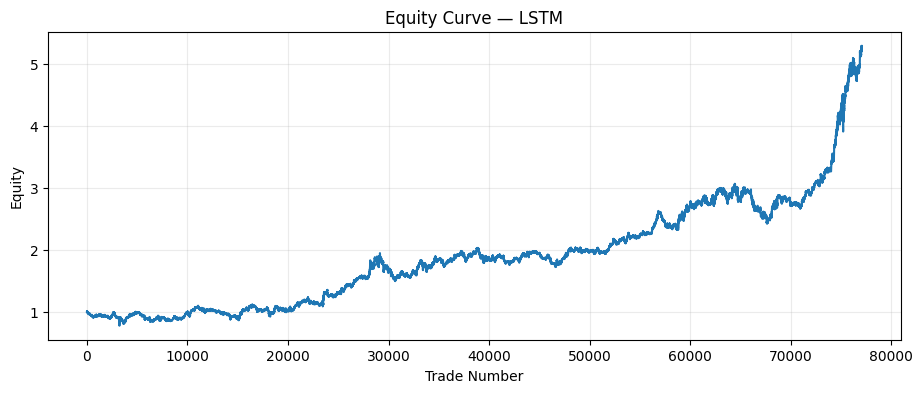

Saved backtest result tables:
/teamspace/studios/this_studio/artifacts/btc_research/results/baseline_backtest_results.csv
/teamspace/studios/this_studio/artifacts/btc_research/results/single_task_backtest_results.csv
/teamspace/studios/this_studio/artifacts/btc_research/results/multitask_backtest_results.csv
/teamspace/studios/this_studio/artifacts/btc_research/results/combined_backtest_results.csv


In [ ]:

# ------------------------------------------------------------
# Event-style backtest utilities for all baselines, single-task
# deep models, and multitask models.
#
# Each prediction is treated as one trade on the aligned future
# log-return target. This is useful for research comparison and
# required financial metrics, but it is not a full exchange-
# level execution simulator.
# ------------------------------------------------------------
from pathlib import Path
import math

BACKTEST_COST_PER_TRADE = 0.0   # decimal simple-return cost per trade, e.g. 0.0005 = 5 bps
BACKTEST_TRADING_DAYS_PER_YEAR = 365.0
MINUTES_PER_YEAR = BACKTEST_TRADING_DAYS_PER_YEAR * 24.0 * 60.0


def make_window_targets_only(y, seq_len, stride=1):
    y = np.asarray(y)
    ends = np.arange(seq_len - 1, len(y), stride)
    return y[ends], ends


# Window-aligned targets for baseline tabular models and sequence models.
yte_ret_tab, test_tab_ends = make_window_targets_only(yte_ret, SEQ_LEN, BASELINE_TEST_STRIDE)
yte_ret_seq = yte_ret[test_ds.ends]

# Optional timestamps if df has a datetime-like index.
try:
    test_index = df.index[test_start:]
    test_time_seq = np.asarray(test_index)[test_ds.ends]
    test_time_tab = np.asarray(test_index)[test_tab_ends]
except Exception:
    test_time_seq = None
    test_time_tab = None


def direction_proba_to_signal(proba_up, threshold=0.5):
    proba_up = np.asarray(proba_up, dtype=np.float32)
    pred = (proba_up >= threshold).astype(np.int64)
    signal = np.where(pred == 1, 1.0, -1.0).astype(np.float32)
    return pred, signal


def compute_event_backtest_from_proba(
    y_future_log_return,
    proba_up,
    threshold=0.5,
    cost_per_trade=0.0,
    model_name="model",
    timestamps=None,
):
    y_future_log_return = np.asarray(y_future_log_return, dtype=np.float32)
    proba_up = np.asarray(proba_up, dtype=np.float32)

    if len(y_future_log_return) != len(proba_up):
        raise ValueError(
            f"Length mismatch in backtest inputs: returns={len(y_future_log_return)} vs proba={len(proba_up)}"
        )

    pred, signal = direction_proba_to_signal(proba_up, threshold=threshold)

    # Treat each sample as one independent trade.
    gross_log_ret = signal * y_future_log_return
    gross_simple_ret = np.expm1(gross_log_ret)

    net_simple_ret = gross_simple_ret - float(cost_per_trade)

    equity_curve = np.cumprod(1.0 + net_simple_ret)
    equity_curve = np.where(np.isfinite(equity_curve), equity_curve, np.nan)

    running_peak = np.maximum.accumulate(np.nan_to_num(equity_curve, nan=1.0))
    drawdown = equity_curve / np.maximum(running_peak, 1e-12) - 1.0
    max_drawdown = float(np.nanmin(drawdown)) if len(drawdown) else np.nan

    win_rate = float(np.mean(net_simple_ret > 0.0)) if len(net_simple_ret) else np.nan
    avg_trade_return = float(np.nanmean(net_simple_ret)) if len(net_simple_ret) else np.nan
    std_trade_return = float(np.nanstd(net_simple_ret, ddof=0)) if len(net_simple_ret) else np.nan
    n_trades = int(len(net_simple_ret))

    # Approx annualization based on how many prediction events occur per year.
    if timestamps is None:
        event_minutes = max(float(HORIZON), 1.0)
    else:
        ts = pd.to_datetime(pd.Series(timestamps)).sort_values()
        if len(ts) >= 2:
            delta_min = ts.diff().dropna().dt.total_seconds().mean() / 60.0
            event_minutes = max(float(delta_min), 1.0)
        else:
            event_minutes = max(float(HORIZON), 1.0)

    events_per_year = max(MINUTES_PER_YEAR / event_minutes, 1.0)

    if std_trade_return > 0:
        sharpe = float((avg_trade_return / std_trade_return) * np.sqrt(events_per_year))
    else:
        sharpe = np.nan

    total_return = float(equity_curve[-1] - 1.0) if len(equity_curve) else np.nan

    out = {
        "model": model_name,
        "n_trades": n_trades,
        "threshold": float(threshold),
        "cost_per_trade": float(cost_per_trade),
        "accuracy": float(accuracy_score((y_future_log_return > 0).astype(np.int64), pred)),
        "win_rate": win_rate,
        "avg_trade_return": avg_trade_return,
        "std_trade_return": std_trade_return,
        "cumulative_return": total_return,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "long_rate": float(np.mean(signal > 0)),
        "short_rate": float(np.mean(signal < 0)),
        "trade_frequency_per_year_est": float(events_per_year),
    }
    details = pd.DataFrame({
        "timestamp": timestamps if timestamps is not None else np.arange(n_trades),
        "future_log_return": y_future_log_return,
        "proba_up": proba_up,
        "pred": pred,
        "signal": signal,
        "gross_simple_ret": gross_simple_ret,
        "net_simple_ret": net_simple_ret,
        "equity": equity_curve,
        "drawdown": drawdown,
    })
    return out, details


def plot_equity_curve(trades_df, title, save_name):
    plt.figure(figsize=(11, 4))
    x = np.arange(len(trades_df))
    plt.plot(x, trades_df["equity"].to_numpy())
    plt.title(title)
    plt.xlabel("Trade Number")
    plt.ylabel("Equity")
    plt.grid(alpha=0.25)
    if save_name:
        out_path = REPORT_DIR / f"{save_name}.png"
        plt.savefig(out_path, dpi=160, bbox_inches="tight")
        print("Saved figure:", out_path)
    plt.show()


# ------------------------------
# Baseline model backtests
# ------------------------------
baseline_backtests = []
baseline_trade_logs = {}

if "baseline_models" in globals() and len(baseline_models) > 0:
    for model_name, model in baseline_models.items():
        threshold = float(baseline_thresholds.get(model_name, FIXED_THRESHOLD))
        proba_up = model.predict_proba(Xte_tab)[:, 1]

        row, trades_df = compute_event_backtest_from_proba(
            y_future_log_return=yte_ret_tab,
            proba_up=proba_up,
            threshold=threshold,
            cost_per_trade=BACKTEST_COST_PER_TRADE,
            model_name=model_name,
            timestamps=test_time_tab,
        )
        baseline_backtests.append(row)
        baseline_trade_logs[model_name] = trades_df

baseline_backtests_df = pd.DataFrame(baseline_backtests)
if len(baseline_backtests_df) > 0:
    baseline_backtests_df = baseline_backtests_df.sort_values(
        ["sharpe", "cumulative_return", "win_rate"], ascending=False
    ).reset_index(drop=True)
    print("Baseline backtest leaderboard:")
    display(baseline_backtests_df)
else:
    print("No baseline backtest results available.")


# ------------------------------
# Single-task deep model backtests
# ------------------------------
deep_backtests = []
deep_trade_logs = {}

if "deep_results" in globals() and len(deep_results) > 0:
    criterion_bt, _ = build_direction_criterion(ytr_dir[train_ds.ends])

    for r in deep_results:
        if r.get("status") != "ok" or r.get("trained_model") is None:
            continue

        model_name = r["model"]
        model = r["trained_model"]
        threshold = float(r.get("threshold", FIXED_THRESHOLD))

        test_metrics = evaluate_direction_model(model, test_loader, criterion_bt, threshold=threshold)
        proba_up = np.asarray(test_metrics["y_proba_up"], dtype=np.float32)

        row, trades_df = compute_event_backtest_from_proba(
            y_future_log_return=yte_ret_seq,
            proba_up=proba_up,
            threshold=threshold,
            cost_per_trade=BACKTEST_COST_PER_TRADE,
            model_name=model_name,
            timestamps=test_time_seq,
        )
        deep_backtests.append(row)
        deep_trade_logs[model_name] = trades_df

deep_backtests_df = pd.DataFrame(deep_backtests)
if len(deep_backtests_df) > 0:
    deep_backtests_df = deep_backtests_df.sort_values(
        ["sharpe", "cumulative_return", "win_rate"], ascending=False
    ).reset_index(drop=True)
    print("Single-task deep backtest leaderboard:")
    display(deep_backtests_df)
else:
    print("No single-task deep backtest results available.")


# ------------------------------
# Multitask model backtests
# ------------------------------
multitask_backtests = []
multitask_trade_logs = {}

if "multitask_results" in globals() and len(multitask_results) > 0:
    dir_criterion_bt, _ = build_direction_criterion(ytr_dir[train_ds.ends])
    regime_criterion_bt = nn.CrossEntropyLoss(weight=regime_class_weight_vec.to(DEVICE))

    for r in multitask_results:
        if r.get("status") != "ok" or r.get("trained_model") is None:
            continue

        model_name = r["model"]
        model = r["trained_model"]
        threshold = float(r.get("threshold", FIXED_THRESHOLD))

        test_metrics = evaluate_multitask_model(
            model,
            test_loader,
            dir_criterion=dir_criterion_bt,
            regime_criterion=regime_criterion_bt,
            dir_threshold=threshold,
        )
        proba_up = np.asarray(test_metrics["y_dir_prob_up"], dtype=np.float32)

        row, trades_df = compute_event_backtest_from_proba(
            y_future_log_return=yte_ret_seq,
            proba_up=proba_up,
            threshold=threshold,
            cost_per_trade=BACKTEST_COST_PER_TRADE,
            model_name=model_name,
            timestamps=test_time_seq,
        )
        row["regime_acc"] = float(test_metrics["regime_acc"])
        row["return_mae"] = float(test_metrics["return_mae"])
        multitask_backtests.append(row)
        multitask_trade_logs[model_name] = trades_df

multitask_backtests_df = pd.DataFrame(multitask_backtests)
if len(multitask_backtests_df) > 0:
    multitask_backtests_df = multitask_backtests_df.sort_values(
        ["sharpe", "cumulative_return", "win_rate"], ascending=False
    ).reset_index(drop=True)
    print("Multitask backtest leaderboard:")
    display(multitask_backtests_df)
else:
    print("No multitask backtest results available.")


# ------------------------------
# Combined backtest comparison
# ------------------------------
combined_backtests_df = pd.concat([
    baseline_backtests_df.assign(task_type="baseline") if len(baseline_backtests_df) > 0 else pd.DataFrame(),
    deep_backtests_df.assign(task_type="single_task_deep") if len(deep_backtests_df) > 0 else pd.DataFrame(),
    multitask_backtests_df.assign(task_type="multitask_deep") if len(multitask_backtests_df) > 0 else pd.DataFrame(),
], ignore_index=True)

if len(combined_backtests_df) > 0:
    combined_backtests_df = combined_backtests_df.sort_values(
        ["sharpe", "cumulative_return", "win_rate"], ascending=False
    ).reset_index(drop=True)

    print("Combined backtest comparison:")
    display(combined_backtests_df)

    best_bt_name = combined_backtests_df.iloc[0]["model"]
    print("Best backtest model:", best_bt_name)

    if best_bt_name in baseline_trade_logs:
        best_bt_trades = baseline_trade_logs[best_bt_name]
    elif best_bt_name in deep_trade_logs:
        best_bt_trades = deep_trade_logs[best_bt_name]
    else:
        best_bt_trades = multitask_trade_logs[best_bt_name]

    plot_equity_curve(
        best_bt_trades,
        title=f"Equity Curve — {best_bt_name}",
        save_name=f"equity_curve_{best_bt_name}",
    )

    # Save CSVs for reporting
    baseline_bt_path = ARTIFACT_ROOT / "results" / "baseline_backtest_results.csv"
    deep_bt_path = ARTIFACT_ROOT / "results" / "single_task_backtest_results.csv"
    multitask_bt_path = ARTIFACT_ROOT / "results" / "multitask_backtest_results.csv"
    combined_bt_path = ARTIFACT_ROOT / "results" / "combined_backtest_results.csv"

    if len(baseline_backtests_df) > 0:
        baseline_backtests_df.to_csv(baseline_bt_path, index=False)
    if len(deep_backtests_df) > 0:
        deep_backtests_df.to_csv(deep_bt_path, index=False)
    if len(multitask_backtests_df) > 0:
        multitask_backtests_df.to_csv(multitask_bt_path, index=False)
    combined_backtests_df.to_csv(combined_bt_path, index=False)

    print("Saved backtest result tables:")
    for p in [baseline_bt_path, deep_bt_path, multitask_bt_path, combined_bt_path]:
        if p.exists():
            print(p)
else:
    print("No combined backtest results available.")
